# 04 — Diagnóstico da validação externa

**Dataset analisado: `Fakerecogna_extrativo.csv`.**

Reúne os diagnósticos e as investigações da avaliação realizada no 03. Execute o 03 primeiro para gerar as previsões e métricas. Este notebook pode ser executado em um kernel novo: carrega os artefatos salvos, confere sua integridade e mantém o ensemble, o PLN, o TF-IDF e o limiar congelados. A versão extrativa permite avaliar robustez, mas sua independência em relação ao corpus de treinamento não está certificada.


## Carregamento do modelo e conferência das partições

A célula abaixo importa as bibliotecas e funções compartilhadas, localiza a raiz do projeto e carrega o bundle do stacking salvo no 02. Confere o manifesto e os hashes das partições para garantir que o modelo, o treino e o holdout pertencem à mesma execução. Verifica textos vazios e sobreposição de textos, IDs e grupos de similaridade entre treino e holdout. Interrompe a execução se encontrar incompatibilidades. Não treina nenhum classificador.

In [1]:
from pathlib import Path
import sys
for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    module_dir = base / "notebooks/v2_validacao_externa"
    if (module_dir / "pipeline_utils.py").is_file():
        sys.path.insert(0, str(module_dir))
        break
else:
    raise FileNotFoundError("Execute dentro do projeto.")
import importlib
import pipeline_utils
importlib.reload(pipeline_utils)
from pipeline_utils import (project_root, compose_text, normalize_text, validate_labels,
                            sha256_file, load_bundle, LABEL_NAMES, SCHEMA_VERSION, MODEL_RELATIVE,
                            INPUT_POLICY, FEATURE_COLUMNS, checking_signals,
                            TRAIN_COLUMNS, PROCESSED_COLUMNS, EXTERNAL_COLUMNS,
                            validate_schema, make_features, prepare_authors,
                            load_manifest, read_partition, fitted_base_features)
ROOT = project_root()
DATA_DIR = ROOT / "notebooks/v2_validacao_externa/data/processed/texto_autor_exploratorio_v4"
import json
import joblib
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from urllib.parse import urlsplit, unquote
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import HashingVectorizer
from typing import cast
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from IPython.display import Markdown, display
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score,
                             balanced_accuracy_score, matthews_corrcoef, average_precision_score,
                             roc_curve, precision_recall_curve)
bundle = load_bundle(ROOT / MODEL_RELATIVE)
model = cast(Pipeline, bundle["pipeline"])
manifest = load_manifest(DATA_DIR)
if manifest != bundle["manifest"]:
    raise ValueError("Modelo e partições pertencem a execuções diferentes.")
for name, expected in manifest["files"].items():
    if sha256_file(DATA_DIR / name) != expected:
        raise ValueError(f"Partição alterada: {name}")
train = read_partition(DATA_DIR / "train.csv")
holdout = read_partition(DATA_DIR / "test_holdout.csv")
validate_schema(train, PROCESSED_COLUMNS, context="treino")
validate_schema(holdout, PROCESSED_COLUMNS, context="holdout")
if holdout.texto.isna().any() or holdout.texto.map(normalize_text).eq("").any():
    raise ValueError("Texto vazio no holdout.")
train_keys = set(train.texto.map(normalize_text))
if not train_keys.isdisjoint(holdout.texto.map(normalize_text)):
    raise ValueError("Sobreposição entre treino e holdout.")
if not set(train.id_original).isdisjoint(holdout.id_original):
    raise ValueError("IDs compartilhados entre treino e holdout.")
if "grupo_similaridade" in train and "grupo_similaridade" in holdout:
    if not set(train.grupo_similaridade).isdisjoint(holdout.grupo_similaridade):
        raise ValueError("Grupo de similaridade compartilhado entre as partições.")


## Carregamento dos resultados da avaliação

Lê as previsões e métricas produzidas no 03, confere os hashes do modelo e do dataset e verifica as quantidades e a matriz de confusão. Interrompe a execução se os artefatos estiverem ausentes ou inconsistentes.


In [2]:
EXTERNAL_PATH = ROOT / "data/fakerecogna_extrativo.csv"
EXTERNAL_DIR = ROOT / "reports/v2_stacking_texto_autor_exploratorio/avaliacao/fakerecogna_extrativo"
for nome in ["metricas.json", "predicoes.csv"]:
    if not (EXTERNAL_DIR / nome).is_file():
        raise FileNotFoundError(f"Execute o 03 antes deste diagnóstico: {nome}")
resultado_externo = json.loads((EXTERNAL_DIR / "metricas.json").read_text(encoding="utf-8"))
if resultado_externo["model_sha256"] != sha256_file(ROOT / MODEL_RELATIVE):
    raise ValueError("O modelo atual difere do modelo avaliado no 03.")
if resultado_externo["data_sha256"] != sha256_file(EXTERNAL_PATH):
    raise ValueError("O dataset foi alterado após a avaliação no 03.")
raw = pd.read_csv(EXTERNAL_PATH).fillna("")
external = pd.read_csv(EXTERNAL_DIR / "predicoes.csv").fillna("")
external_metrics = resultado_externo["metrics"]
matriz = np.asarray(external_metrics["confusion_matrix"])
if len(external) != resultado_externo["n_avaliado"] or len(raw) != resultado_externo["n_original"]:
    raise ValueError("As quantidades diferem da avaliação salva no 03.")
if not np.array_equal(confusion_matrix(validate_labels(external.label),
                                     validate_labels(external.predito), labels=[0, 1]), matriz):
    raise ValueError("As previsões diferem da matriz de confusão salva.")


## TF-IDF — cobertura do vocabulário no holdout
Usa o mesmo analyzer do TF-IDF. A taxa abaixo se refere a atributos candidatos (unigramas e bigramas), não a palavras únicas. Margens são escores, não probabilidades.

Para cada base do stacking, percorre os atributos produzidos pelo analyzer já ajustado e calcula a fração fora do vocabulário no holdout. Também informa autores inéditos e entradas sem atributos textuais conhecidos. Apenas consulta os transformadores existentes; não altera o vocabulário.

Esta célula consulta explicitamente os vetorizadores **TF-IDF** de cada base e seus analyzers de **PLN**. Mede atributos fora do vocabulário e entradas sem atributos conhecidos usando transform, sem fit.

In [3]:
# Cada base possui seu próprio TF-IDF ajustado no treino completo.
stacking_ajustado = cast(StackingClassifier, model.named_steps["clf"])
for nome, base in stacking_ajustado.named_estimators_.items():
    vectorizer, encoder = fitted_base_features(base)
    analyzer = vectorizer.build_analyzer()
    vocab = set(vectorizer.vocabulary_)
    total = 0
    desconhecidos = 0
    for text in holdout.texto:
        for term in analyzer(text):
            total += 1
            desconhecidos += int(term not in vocab)
    print(nome, "— fração de atributos fora do vocabulário:",
          desconhecidos / total if total else None)
    autores = prepare_authors(holdout).ravel()
    conhecidos = set(np.asarray(encoder.categories_[0]).ravel().tolist())
    print("Fração de autores inéditos:", float(np.mean([a not in conhecidos for a in autores])))
    print("Entradas sem atributos textuais conhecidos:",
          int((vectorizer.transform(holdout.texto).getnnz(axis=1) == 0).sum()))


regressao_logistica — fração de atributos fora do vocabulário: 0.42549574483523545
Fração de autores inéditos: 0.10486577181208054
Entradas sem atributos textuais conhecidos: 0
random_forest — fração de atributos fora do vocabulário: 0.42549574483523545
Fração de autores inéditos: 0.10486577181208054
Entradas sem atributos textuais conhecidos: 0
svc — fração de atributos fora do vocabulário: 0.42549574483523545
Fração de autores inéditos: 0.10486577181208054
Entradas sem atributos textuais conhecidos: 0


## Diagnóstico inicial — quantidades e erros por classe

Compara os rótulos do dataset original, os registros efetivamente avaliados e as classes previstas pelo ensemble. Apresenta as métricas salvas e as limitações da independência do corpus.


In [4]:
diagnostico = f"""# Diagnóstico — FakeRecogna extrativo

## Quantidades por classe

| Etapa | Fake | Real | Total |
|---|---:|---:|---:|
| Dataset original, segundo os rótulos | {np.count_nonzero(pd.to_numeric(raw["Label"]).to_numpy() == 1):,} | {np.count_nonzero(pd.to_numeric(raw["Label"]).to_numpy() == 0):,} | {len(raw):,} |
| Subconjunto avaliado, segundo os rótulos | {matriz[0].sum():,} | {matriz[1].sum():,} | {len(external):,} |
| Previsões do ensemble no subconjunto avaliado | {matriz[:, 0].sum():,} | {matriz[:, 1].sum():,} | {len(external):,} |

O ensemble foi aplicado somente aos registros retidos após a auditoria. As quantidades do dataset representam seus rótulos de referência, sem checagem independente integral.

Registros originais: {len(raw)}. Avaliados: {len(external)}.
F1-macro: {external_metrics['f1_macro']:.4f}. Acurácia: {external_metrics['accuracy']:.4f}.
Fake como Real: {matriz[0, 1]}; Real como Fake: {matriz[1, 0]}.

Foram bloqueadas coincidências de URL, título, texto e similaridade elevada com o corpus original.
A exclusão automática não comprova independência por evento. O corpus é uma versão extrativa do FakeRecogna e o resultado deve ser apresentado como avaliação de robustez, não certificação OOD.
Título e autor podem conter marcas de checagem. O mapeamento externo é 1 = Fake e 0 = Real; divergências de URLs correspondentes foram registradas.
Não foi feita revisão integral das fontes. O ensemble e seu TF-IDF permaneceram congelados. Novos ajustes exigem outro teste independente.
"""
(EXTERNAL_DIR / "diagnostico.md").write_text(diagnostico, encoding="utf-8")
print(diagnostico)


# Diagnóstico — FakeRecogna extrativo

## Quantidades por classe

| Etapa | Fake | Real | Total |
|---|---:|---:|---:|
| Dataset original, segundo os rótulos | 26,400 | 26,400 | 52,800 |
| Subconjunto avaliado, segundo os rótulos | 21,300 | 24,929 | 46,229 |
| Previsões do ensemble no subconjunto avaliado | 11,502 | 34,727 | 46,229 |

O ensemble foi aplicado somente aos registros retidos após a auditoria. As quantidades do dataset representam seus rótulos de referência, sem checagem independente integral.

Registros originais: 52800. Avaliados: 46229.
F1-macro: 0.7675. Acurácia: 0.7871.
Fake como Real: 9819; Real como Fake: 21.

Foram bloqueadas coincidências de URL, título, texto e similaridade elevada com o corpus original.
A exclusão automática não comprova independência por evento. O corpus é uma versão extrativa do FakeRecogna e o resultado deve ser apresentado como avaliação de robustez, não certificação OOD.
Título e autor podem conter marcas de checagem. O mapeamento externo é 

## Diagnóstico avançado — rótulos de referência versus previsões

Carrega apenas os resultados do CSV extrativo e verifica seus hashes. Compara a composição original, a composição retida e as classes previstas. Recalcula métricas, erros por classe e a referência de prever sempre a classe majoritária, sem treinar modelos. Os rótulos do arquivo são a referência operacional, não uma comprovação independente da veracidade das notícias. O protocolo continua sendo de robustez em corpus derivado.

In [5]:
DIAG_DIR = ROOT / "reports/v2_stacking_texto_autor_exploratorio/avaliacao/fakerecogna_extrativo/diagnostico_avancado"
DIAG_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR = DIAG_DIR.parent
resultado = json.loads((RESULT_DIR / "metricas.json").read_text(encoding="utf-8"))
if sha256_file(ROOT / "data/fakerecogna_extrativo.csv") != resultado["data_sha256"]:
    raise ValueError("O CSV original mudou após as previsões.")
if sha256_file(ROOT / MODEL_RELATIVE) != resultado["model_sha256"]:
    raise ValueError("O modelo mudou após as previsões.")
diagnostico_dados = pd.read_csv(RESULT_DIR / "predicoes.csv", keep_default_na=False)
original_externo = pd.read_csv(ROOT / "data/fakerecogna_extrativo.csv", keep_default_na=False)
y_ref = validate_labels(diagnostico_dados.label).to_numpy()
y_pred = validate_labels(diagnostico_dados.predito).to_numpy()
if diagnostico_dados.id_externo.duplicated().any() or len(y_ref) != resultado["n_avaliado"]:
    raise ValueError("Previsões duplicadas ou incompletas.")
label_original = validate_labels(pd.to_numeric(original_externo.Label).map({0: 1, 1: 0}))
if not np.array_equal(y_ref, label_original.iloc[diagnostico_dados.id_externo.to_numpy(dtype=int)].to_numpy()):
    raise ValueError("Rótulos das previsões não correspondem ao CSV original.")
matriz_diag = confusion_matrix(y_ref, y_pred, labels=[0, 1])
if matriz_diag.tolist() != resultado["metrics"]["confusion_matrix"]:
    raise ValueError("A matriz recalculada difere do resultado salvo.")
comparativo_classes = pd.DataFrame({"classe": ["Fake", "Real"],
    "referencia_original": [len(label_original.loc[label_original.eq(k)]) for k in [0, 1]],
    "referencia_avaliada": [int(np.count_nonzero(y_ref == k)) for k in [0, 1]],
    "previsao_ensemble": [int(np.count_nonzero(y_pred == k)) for k in [0, 1]]})
comparativo_classes["excluidos"] = comparativo_classes.referencia_original - comparativo_classes.referencia_avaliada
comparativo_classes["referencia_percentual"] = 100 * comparativo_classes.referencia_avaliada / len(y_ref)
comparativo_classes["previsao_percentual"] = 100 * comparativo_classes.previsao_ensemble / len(y_ref)
comparativo_classes["diferenca_pp"] = comparativo_classes.previsao_percentual - comparativo_classes.referencia_percentual
comparativo_classes.to_csv(DIAG_DIR / "referencia_vs_previsao.csv", index=False)
display(comparativo_classes)
majoritaria = int(np.argmax(np.bincount(y_ref, minlength=2)))
baseline = np.full(y_ref.shape, majoritaria, dtype=int)
escores = diagnostico_dados.margem_real.to_numpy(dtype=float)
metricas_diag = {"n": len(y_ref), "accuracy": float(accuracy_score(y_ref, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_ref, y_pred)),
    "f1_macro": float(f1_score(y_ref, y_pred, average="macro")),
    "mcc": float(matthews_corrcoef(y_ref, y_pred)),
    "roc_auc_real": float(roc_auc_score(y_ref, escores)),
    "average_precision_fake": float(average_precision_score(1 - y_ref, -escores)),
    "baseline_accuracy": float(accuracy_score(y_ref, baseline)),
    "baseline_f1_macro": float(f1_score(y_ref, baseline, labels=[0, 1], average="macro", zero_division=0)),
    "recall_fake": float(matriz_diag[0, 0] / matriz_diag[0].sum()),
    "recall_real": float(matriz_diag[1, 1] / matriz_diag[1].sum()),
    "fake_como_real": int(matriz_diag[0, 1]), "real_como_fake": int(matriz_diag[1, 0]),
    "confusion_matrix": matriz_diag.tolist()}
(DIAG_DIR / "metricas_diagnostico.json").write_text(json.dumps(metricas_diag, indent=2, ensure_ascii=False), encoding="utf-8")
display(pd.Series({k: v for k, v in metricas_diag.items() if k != "confusion_matrix"}))


,classe,referencia_original,referencia_avaliada,previsao_ensemble,excluidos,referencia_percentual,previsao_percentual,diferenca_pp
0,Fake,26400,21300,11502,5100,46.074975,24.880486,-21.194488
1,Real,26400,24929,34727,1471,53.925025,75.119514,21.194488


n                         46229.000000
accuracy                      0.787147
balanced_accuracy             0.769086
f1_macro                      0.767536
mcc                           0.620501
roc_auc_real                  0.987251
average_precision_fake        0.987165
baseline_accuracy             0.539250
baseline_f1_macro             0.350333
recall_fake                   0.539014
recall_real                   0.999158
fake_como_real             9819.000000
real_como_fake               21.000000
dtype: float64

## PLN e metadados — diagnóstico por fonte, autoria, comprimento e sinais editoriais

Agrupa os erros por domínio da URL, categoria, autor conhecido ou inédito, faixa de comprimento e presença de sinais editoriais. A autoria é comparada ao conjunto de treinamento com a mesma normalização de PLN. Os agrupamentos não são novas features nem mudam as previsões. Relações observadas são descritivas, não demonstram causas. Grupos pequenos ou com uma só classe são identificados para evitar conclusões indevidas.

In [6]:
diagnostico_dados["fonte"] = diagnostico_dados.URL.map(lambda value: urlsplit(str(value)).hostname or "fonte_desconhecida")
if "Categoria" in diagnostico_dados:
    diagnostico_dados["categoria_auditoria"] = diagnostico_dados.Categoria.astype(str).str.strip().str.casefold().replace("", "ausente")
else:
    diagnostico_dados["categoria_auditoria"] = "ausente"
autores_treino = set(prepare_authors(train).ravel())
autores_teste = prepare_authors(diagnostico_dados).ravel()
diagnostico_dados["autor_conhecido"] = [a in autores_treino for a in autores_teste]
diagnostico_dados["autor_ausente"] = diagnostico_dados.Autor.astype(str).str.strip().eq("")
diagnostico_dados["faixa_palavras"] = pd.cut(diagnostico_dados.palavras, bins=[-1, 50, 150, 400, np.inf],
    labels=["até 50", "51–150", "151–400", "mais de 400"]).astype(str)
diagnostico_dados["sinal_editorial"] = diagnostico_dados.pistas_editoriais.ne("")
diagnostico_dados["acerto_diagnostico"] = y_ref == y_pred
diagnostico_dados["tipo_resultado"] = np.where(y_ref == y_pred, "acerto",
    np.where(y_ref == 0, "Fake como Real", "Real como Fake"))
registros_grupos = []
for campo in ["fonte", "categoria_auditoria", "autor_conhecido", "autor_ausente", "faixa_palavras", "sinal_editorial"]:
    for grupo_nome, grupo in diagnostico_dados.groupby(campo, observed=True):
        verdade = grupo.label.to_numpy(dtype=int)
        previsto = grupo.predito.to_numpy(dtype=int)
        n_fake = int(np.count_nonzero(verdade == 0))
        n_real = int(np.count_nonzero(verdade == 1))
        registros_grupos.append({"campo": campo, "grupo": str(grupo_nome), "n": len(grupo),
            "n_fake": n_fake, "n_real": n_real,
            "accuracy": float(accuracy_score(verdade, previsto)),
            "f1_macro": float(f1_score(verdade, previsto, labels=[0, 1], average="macro", zero_division=0)),
            "recall_fake": float(np.count_nonzero((verdade == 0) & (previsto == 0)) / n_fake) if n_fake else None,
            "recall_real": float(np.count_nonzero((verdade == 1) & (previsto == 1)) / n_real) if n_real else None,
            "fake_como_real": int(np.count_nonzero((verdade == 0) & (previsto == 1))),
            "real_como_fake": int(np.count_nonzero((verdade == 1) & (previsto == 0))),
            "grupo_pequeno": len(grupo) < 30, "ambas_classes": n_fake > 0 and n_real > 0})
metricas_grupos = pd.DataFrame(registros_grupos)
metricas_grupos.to_csv(DIAG_DIR / "metricas_por_grupo.csv", index=False)
display(metricas_grupos.sort_values("n", ascending=False).head(30))
resumo_margens = diagnostico_dados.groupby(["label", "predito"]).margem_real.agg(["size", "min", "median", "max"])
resumo_margens.to_csv(DIAG_DIR / "margens_por_resultado.csv")
display(resumo_margens)
# Exemplos com margem extrema são amostras para auditoria, não rótulos corrigidos.
exemplos = diagnostico_dados.loc[~diagnostico_dados.acerto_diagnostico].copy()
exemplos["margem_absoluta"] = exemplos.margem_real.abs()
exemplos.sort_values("margem_absoluta", ascending=False).head(100).to_csv(DIAG_DIR / "erros_margem_extrema.csv", index=False)


,campo,grupo,n,n_fake,n_real,accuracy,f1_macro,recall_fake,recall_real,fake_como_real,real_como_fake,grupo_pequeno,ambas_classes
87,autor_ausente,False,44618,20345,24273,0.799991,0.782017,0.562349,0.999176,8904,20,False,True
93,sinal_editorial,False,34368,10014,24354,0.794722,0.665266,0.296585,0.999548,7044,11,False,True
90,faixa_palavras,51–150,32633,10040,22593,0.839457,0.771980,0.480179,0.999115,5219,20,False,True
86,autor_conhecido,True,28514,9040,19474,0.955285,0.946271,0.860619,0.999230,1260,15,False,True
85,autor_conhecido,False,17715,12260,5455,0.516511,0.511758,0.301876,0.998900,8559,6,False,True
77,categoria_auditoria,saúde,12980,864,12116,0.990524,0.959580,0.868056,0.999257,114,9,False,True
94,sinal_editorial,True,11861,11286,575,0.765197,0.574013,0.754120,0.982609,2775,10,False,True
4,fonte,fonte_desconhecida,11446,0,11446,0.999388,0.499847,NaN,0.999388,0,7,False,False
91,faixa_palavras,até 50,9916,9420,496,0.594090,0.462880,0.572824,0.997984,4024,1,False,True
75,categoria_auditoria,política,9478,2817,6661,0.976788,0.971603,0.924388,0.998949,213,7,False,True


size        min    median        max
label predito                                       
0     0        11481 -20.510987 -5.526066  -0.000351
      1         9819   0.000167  1.785692   9.978347
1     0           21  -1.906873 -0.493899  -0.083506
      1        24908   0.025643  6.516332  12.150943

## Comparativo interno, curvas e interpretação avançada

Compara OOF, holdout e corpus extrativo sem misturar suas origens. Desenha rótulos versus previsões, confusão por classe, ROC, precisão–recall e recall de Fake por fonte. ROC-AUC mede ordenação de escores; não substitui a sensibilidade do classificador no ponto de decisão atual. Margens não são probabilidades calibradas. Gera um relatório técnico com resultados, limitações e recomendações, sem ajustar limiares usando este conjunto.

,avaliacao,n,accuracy,f1_macro,recall_fake,recall_real
0,OOF interno,9518,0.990019,0.990019,0.988005,0.992027
1,Holdout interno,2384,0.993289,0.993289,0.990826,0.995781
2,Extrativo — robustez,46229,0.787147,0.767536,0.539014,0.999158


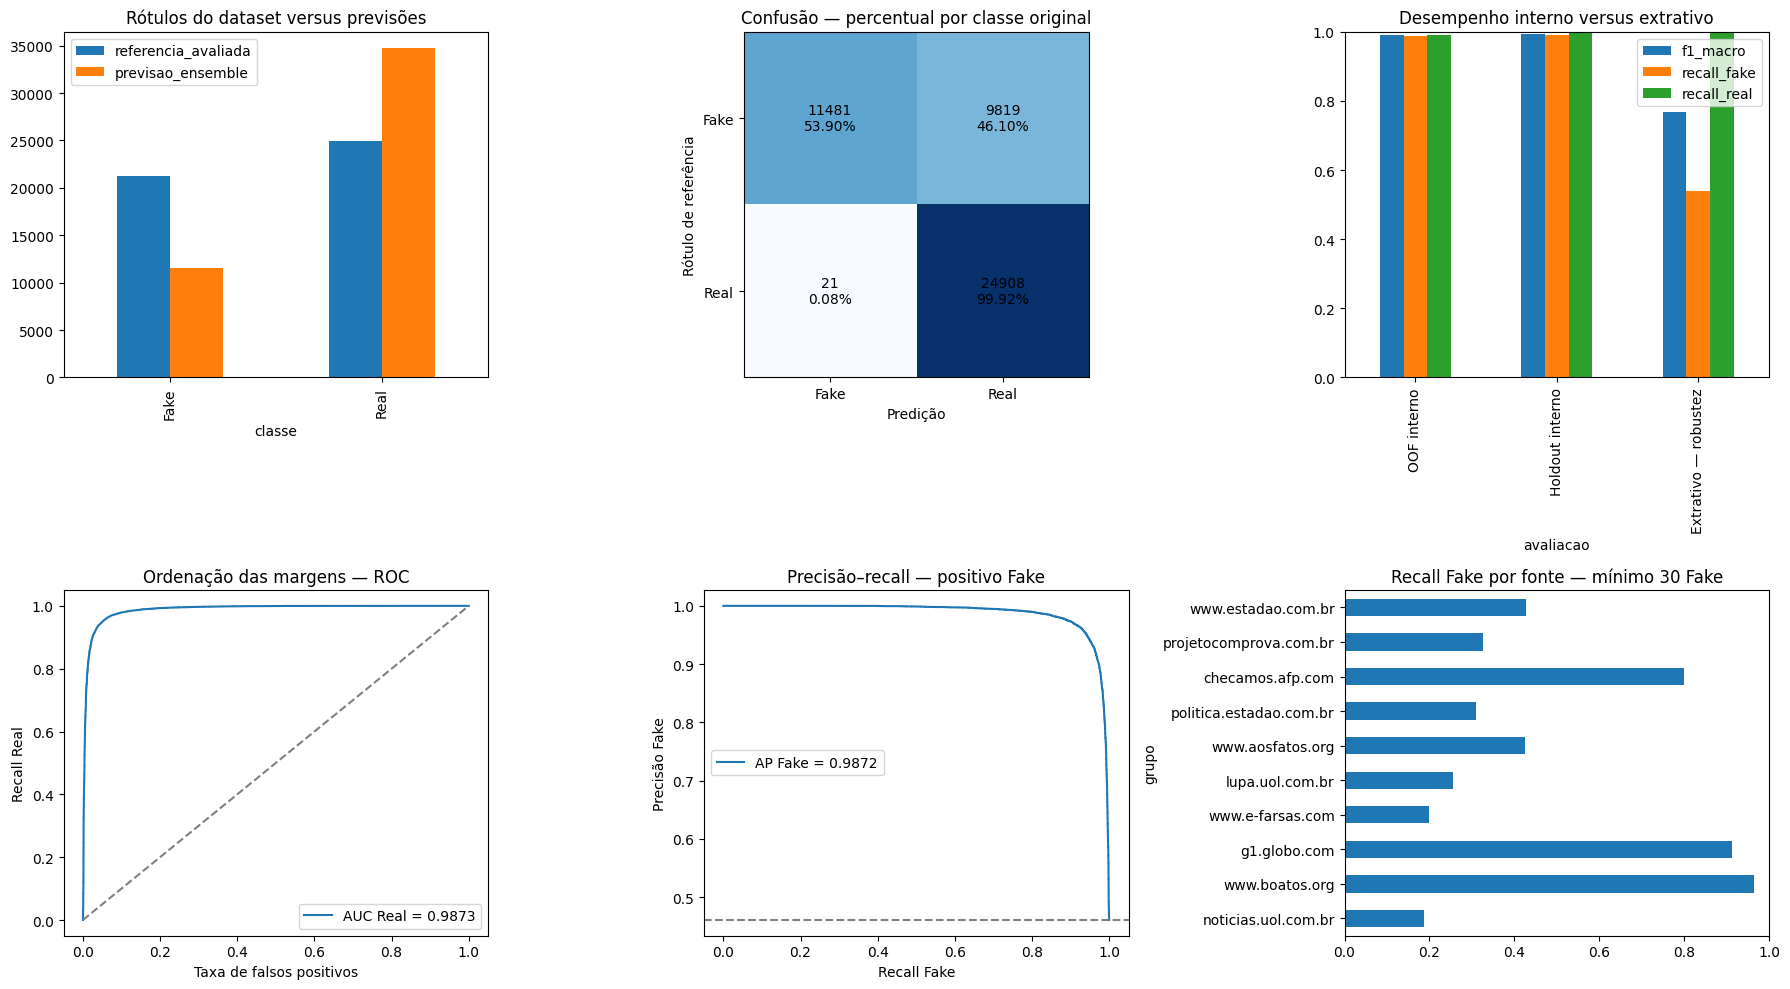

# Diagnóstico avançado — ensemble versus rótulos do corpus extrativo

## Quantidades por classe

| Etapa | Fake | Real | Total |
|---|---:|---:|---:|
| Dataset original, segundo os rótulos | 26,400 | 26,400 | 52,800 |
| Subconjunto avaliado, segundo os rótulos | 21,300 | 24,929 | 46,229 |
| Previsões do ensemble no subconjunto avaliado | 11,502 | 34,727 | 46,229 |

O ensemble foi aplicado somente ao subconjunto retido. O dataset completo e o subconjunto avaliado têm tamanhos diferentes; suas contagens não devem ser comparadas como se todos os registros tivessem recebido previsões.

## O que o dataset apresenta

O arquivo contém 52,800 registros, com Label 1 = Fake e Label 0 = Real.
Após as exclusões, a avaliação contém 46,229: 21,300 Fake e 24,929 Real.
Os rótulos são a referência do arquivo, sem verificação independente integral das fontes.
A seleção altera a composição original: compare referencia_vs_previsao.csv e auditoria_inicial.csv.

## O que o ensemble prevê

O ensemble prevê 1

In [7]:
oof = json.loads((ROOT / "reports/v2_stacking_texto_autor_exploratorio/stacking/metricas_cv.json").read_text(encoding="utf-8"))
holdout_resultado = json.loads((RESULT_DIR.parent / "holdout_metrics.json").read_text(encoding="utf-8"))["holdout"]
comparativo_experimentos = pd.DataFrame([
    {"avaliacao": "OOF interno", "n": oof["n"], "accuracy": oof["accuracy_oof"], "f1_macro": oof["f1_macro_oof"],
     "recall_fake": oof["classification_report"]["Fake"]["recall"], "recall_real": oof["classification_report"]["Real"]["recall"]},
    {"avaliacao": "Holdout interno", "n": holdout_resultado["n"], "accuracy": holdout_resultado["accuracy"], "f1_macro": holdout_resultado["f1_macro"],
     "recall_fake": holdout_resultado["classification_report"]["Fake"]["recall"], "recall_real": holdout_resultado["classification_report"]["Real"]["recall"]},
    {"avaliacao": "Extrativo — robustez", "n": len(y_ref), "accuracy": metricas_diag["accuracy"], "f1_macro": metricas_diag["f1_macro"],
     "recall_fake": metricas_diag["recall_fake"], "recall_real": metricas_diag["recall_real"]}])
comparativo_experimentos.to_csv(DIAG_DIR / "comparativo_experimentos.csv", index=False)
display(comparativo_experimentos)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
comparativo_classes.set_index("classe")[["referencia_avaliada", "previsao_ensemble"]].plot.bar(ax=axes[0, 0])
axes[0, 0].set_title("Rótulos do dataset versus previsões")
normalizada = matriz_diag / matriz_diag.sum(axis=1, keepdims=True)
axes[0, 1].imshow(normalizada, vmin=0, vmax=1, cmap="Blues")
for i in range(2):
    for j in range(2):
        axes[0, 1].text(j, i, f"{matriz_diag[i, j]}\n{100 * normalizada[i, j]:.2f}%", ha="center", va="center")
axes[0, 1].set_xticks([0, 1], ["Fake", "Real"])
axes[0, 1].set_yticks([0, 1], ["Fake", "Real"])
axes[0, 1].set_xlabel("Predição")
axes[0, 1].set_ylabel("Rótulo de referência")
axes[0, 1].set_title("Confusão — percentual por classe original")
comparativo_experimentos.set_index("avaliacao")[["f1_macro", "recall_fake", "recall_real"]].plot.bar(ax=axes[0, 2])
axes[0, 2].set_ylim(0, 1)
axes[0, 2].set_title("Desempenho interno versus extrativo")
fpr, tpr, _ = roc_curve(y_ref, escores)
axes[1, 0].plot(fpr, tpr, label=f"AUC Real = {metricas_diag['roc_auc_real']:.4f}")
axes[1, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[1, 0].set_xlabel("Taxa de falsos positivos")
axes[1, 0].set_ylabel("Recall Real")
axes[1, 0].set_title("Ordenação das margens — ROC")
axes[1, 0].legend()
precisao, recall, _ = precision_recall_curve(1 - y_ref, -escores)
axes[1, 1].plot(recall, precisao, label=f"AP Fake = {metricas_diag['average_precision_fake']:.4f}")
axes[1, 1].axhline(float(np.mean(y_ref == 0)), linestyle="--", color="gray")
axes[1, 1].set_xlabel("Recall Fake")
axes[1, 1].set_ylabel("Precisão Fake")
axes[1, 1].set_title("Precisão–recall — positivo Fake")
axes[1, 1].legend()
fontes_diag = metricas_grupos.loc[metricas_grupos.campo.eq("fonte") & metricas_grupos.n_fake.ge(30)]
fontes_diag = fontes_diag.sort_values("n", ascending=False).head(12).set_index("grupo")
fontes_diag["recall_fake"].plot.barh(ax=axes[1, 2])
axes[1, 2].set_xlim(0, 1)
axes[1, 2].set_title("Recall Fake por fonte — mínimo 30 Fake")
fig.tight_layout()
for extensao in ["png", "svg"]:
    fig.savefig(DIAG_DIR / f"comparativo_avancado.{extensao}", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
linha_fake = comparativo_classes.loc[comparativo_classes.classe.eq("Fake")].iloc[0]
queda_f1 = holdout_resultado["f1_macro"] - metricas_diag["f1_macro"]
texto_avancado = f"""# Diagnóstico avançado — ensemble versus rótulos do corpus extrativo

## Quantidades por classe

| Etapa | Fake | Real | Total |
|---|---:|---:|---:|
| Dataset original, segundo os rótulos | {np.count_nonzero(label_original.to_numpy() == 0):,} | {np.count_nonzero(label_original.to_numpy() == 1):,} | {len(original_externo):,} |
| Subconjunto avaliado, segundo os rótulos | {matriz_diag[0].sum():,} | {matriz_diag[1].sum():,} | {len(y_ref):,} |
| Previsões do ensemble no subconjunto avaliado | {np.count_nonzero(y_pred == 0):,} | {np.count_nonzero(y_pred == 1):,} | {len(y_pred):,} |

O ensemble foi aplicado somente ao subconjunto retido. O dataset completo e o subconjunto avaliado têm tamanhos diferentes; suas contagens não devem ser comparadas como se todos os registros tivessem recebido previsões.

## O que o dataset apresenta

O arquivo contém {len(original_externo):,} registros, com Label 1 = Fake e Label 0 = Real.
Após as exclusões, a avaliação contém {len(y_ref):,}: {matriz_diag[0].sum():,} Fake e {matriz_diag[1].sum():,} Real.
Os rótulos são a referência do arquivo, sem verificação independente integral das fontes.
A seleção altera a composição original: compare referencia_vs_previsao.csv e auditoria_inicial.csv.

## O que o ensemble prevê

O ensemble prevê {np.count_nonzero(y_pred == 0):,} Fake e {np.count_nonzero(y_pred == 1):,} Real.
A classe Fake representa {linha_fake['referencia_percentual']:.2f}% da referência e {linha_fake['previsao_percentual']:.2f}% das previsões.
Diferença: {linha_fake['diferenca_pp']:+.2f} pontos percentuais. O modelo subestima a frequência de Fake neste conjunto.

| Rótulo do dataset | Previsto Fake | Previsto Real |
|---|---:|---:|
| Fake | {matriz_diag[0, 0]:,} | {matriz_diag[0, 1]:,} |
| Real | {matriz_diag[1, 0]:,} | {matriz_diag[1, 1]:,} |

## Qualidade da decisão

Acurácia: {metricas_diag['accuracy']:.4f}; F1-macro: {metricas_diag['f1_macro']:.4f}.
Acurácia balanceada: {metricas_diag['balanced_accuracy']:.4f}; MCC: {metricas_diag['mcc']:.4f}.
Recall Fake: {metricas_diag['recall_fake']:.4f}; recall Real: {metricas_diag['recall_real']:.4f}.
O classificador deixa passar {100 * (1 - metricas_diag['recall_fake']):.2f}% dos registros rotulados Fake.
A referência de prever sempre {LABEL_NAMES[majoritaria]} obtém acurácia {metricas_diag['baseline_accuracy']:.4f} e F1-macro {metricas_diag['baseline_f1_macro']:.4f}.

ROC-AUC Real: {metricas_diag['roc_auc_real']:.4f}; average precision Fake: {metricas_diag['average_precision_fake']:.4f}.
Uma AUC elevada indica boa ordenação relativa das margens nesta amostra, mas não elimina os erros no ponto de decisão usado por predict.
As margens não são probabilidades calibradas; esta análise não ajustou o limiar usando o teste.

## Comparativo com o experimento interno

F1-macro OOF interno: {oof['f1_macro_oof']:.4f}; holdout interno: {holdout_resultado['f1_macro']:.4f}; extrativo: {metricas_diag['f1_macro']:.4f}.
A diferença entre holdout e extrativo é {queda_f1:.4f} de F1-macro.
Esses testes têm diferentes entradas, seleção e origem; a diferença não é uma comparação causal controlada.
O desempenho interno elevado não garante recuperação das notícias falsas no corpus extrativo.

## Grupos e possíveis explicações

metricas_por_grupo.csv apresenta fontes, categorias, autoria conhecida/ausente, comprimentos e sinais editoriais com suporte por classe.
Grupos pequenos ou com apenas uma classe não sustentam comparações fortes. Fonte e autoria podem funcionar como atalhos.
Resumos extrativos, mudanças de comprimento, autoria e títulos de checagem podem contribuir para o comportamento observado; a análise descritiva não isola esses efeitos.
Nenhuma previsão foi usada para inverter rótulos ou decidir exclusões.

## Limitações e recomendações

O corpus é derivado do FakeRecogna. As exclusões de URL, título, texto e similaridade elevada não garantem independência por evento.
Título e autoria podem revelar a fonte ou o processo de checagem. Os resultados medem robustez e não certificam OOD.
Priorize recall Fake e os erros por classe, além de F1-macro. Revise exemplos e divergências de rótulos com as fontes antes de atribuir erros ao modelo.
Se for necessário estudar calibração ou outro limiar, faça isso em desenvolvimento ou validação separada, com um novo teste independente para confirmação.
Preserve este modelo congelado e estes resultados como registro do protocolo executado.
"""
(DIAG_DIR / "diagnostico_avancado.md").write_text(texto_avancado, encoding="utf-8")
print(texto_avancado)


## Onde o ensemble está errando — evidências e hipóteses

A célula abaixo usa somente as previsões salvas e as métricas por grupo do corpus extrativo. Explica a diferença entre precisão e recall de Fake, identifica os grupos com mais falsos negativos e registra hipóteses de dependência de autoria, fonte e sinais editoriais. As relações são descritivas e não estabelecem causalidade. Nenhum modelo ou limiar é ajustado nesta etapa.

In [8]:
DIAG_DIR = ROOT / "reports/v2_stacking_texto_autor_exploratorio/avaliacao/fakerecogna_extrativo/diagnostico_avancado"
resultado_erros = json.loads((DIAG_DIR.parent / "metricas.json").read_text(encoding="utf-8"))["metrics"]
grupos_erros = pd.read_csv(DIAG_DIR / "metricas_por_grupo.csv")
matriz_erros = np.asarray(resultado_erros["confusion_matrix"])
fn = int(matriz_erros[0, 1])
fp = int(matriz_erros[1, 0])
relatorio_classes = resultado_erros["classification_report"]
fontes_erros = grupos_erros.loc[grupos_erros.campo.eq("fonte")].sort_values("fake_como_real", ascending=False).head(6)
def percentual(valor):
    return f"{100 * valor:.2f}%".replace(".", ",")
def grupo_diagnostico(campo, grupo):
    selecao = grupos_erros.loc[grupos_erros.campo.eq(campo) & grupos_erros.grupo.astype(str).eq(grupo)]
    if len(selecao) != 1:
        raise ValueError(f"Grupo não encontrado ou ambíguo: {campo}/{grupo}")
    return selecao.iloc[0]
ineditos = grupo_diagnostico("autor_conhecido", "False")
conhecidos = grupo_diagnostico("autor_conhecido", "True")
sem_sinal = grupo_diagnostico("sinal_editorial", "False")
com_sinal = grupo_diagnostico("sinal_editorial", "True")
texto_medio = grupo_diagnostico("faixa_palavras", "51–150")
tabela_fontes = "| Fonte da URL | Fake no grupo | Fake previstos como Real | Recall Fake |\n|---|---:|---:|---:|\n"
for linha in fontes_erros.itertuples(index=False):
    tabela_fontes += f"| {linha.grupo} | {linha.n_fake} | {linha.fake_como_real} | {percentual(linha.recall_fake)} |\n"
secao_erros = f"""## Onde o ensemble está errando — evidências e hipóteses

### Erro dominante: aceitar Fake como Real

Acurácia: {percentual(resultado_erros['accuracy'])}; F1-macro: {resultado_erros['f1_macro']:.4f}.
Recall Fake: {percentual(relatorio_classes['Fake']['recall'])}; precisão Fake: {percentual(relatorio_classes['Fake']['precision'])}; recall Real: {percentual(relatorio_classes['Real']['recall'])}.

O ensemble erra sobretudo ao classificar registros rotulados Fake como Real: {fn} casos, contra {fp} registros Real classificados como Fake.
Os falsos negativos de Fake correspondem a {percentual(fn / (fn + fp))} de todos os erros.
A precisão Fake elevada significa que quase todos os registros que o modelo chama de Fake têm esse rótulo na referência.
O recall Fake baixo significa que ele reconhece apenas {percentual(relatorio_classes['Fake']['recall'])} dos Fake existentes: deixa passar {percentual(1 - relatorio_classes['Fake']['recall'])}.
Portanto, uma precisão de 99,82% não indica que o modelo detecta 99,82% das notícias falsas, nem representa confiança calibrada por notícia.

### Onde os erros se concentram

{tabela_fontes}
As contagens dependem do tamanho e da composição dos grupos; a URL identifica a fonte registrada no corpus, muitas vezes o site de checagem, não o autor original da alegação.

- Autoria inédita no treinamento: {int(ineditos['fake_como_real'])} Fake como Real, com recall Fake de {percentual(ineditos['recall_fake'])}. Esse grupo concentra {percentual(float(ineditos['fake_como_real']) / fn)} dos falsos negativos. Autoria conhecida: recall Fake de {percentual(conhecidos['recall_fake'])}.
- Sem sinais editoriais detectados: recall Fake de {percentual(sem_sinal['recall_fake'])}; com sinais: {percentual(com_sinal['recall_fake'])}. A triagem textual não confirma contaminação em cada registro.
- Texto composto com 51–150 palavras: {int(texto_medio['fake_como_real'])} Fake como Real, com recall Fake de {percentual(texto_medio['recall_fake'])}. Esse comprimento inclui título e notícia; o alto número de erros também reflete o tamanho do grupo.

### Hipóteses sobre o comportamento

1. O modelo pode depender de autores/fontes conhecidos: o contraste de recall entre autoria conhecida e inédita é compatível com uso de atalhos de origem. Os grupos têm composição diferente; isso não prova que a autoria causou os erros.
2. Marcas editoriais de checagem podem facilitar a classe Fake no treinamento. O desempenho menor sem esses sinais é compatível com essa hipótese, mas também pode refletir diferenças de fonte, conteúdo e comprimento.
3. A versão extrativa muda o conteúdo e o comprimento do texto recebido pelo TF-IDF. Isso pode deslocar as margens e prejudicar a decisão; a presente análise não isolou o efeito do resumo.
4. A ROC-AUC elevada ({resultado_erros['roc_auc_real']:.4f}) e o recall Fake baixo sugerem que a ordenação dos escores é melhor que a decisão atual neste conjunto. Isso não autoriza escolher um novo limiar neste teste para depois reportá-lo como confirmação independente.
5. Os rótulos da base são referência operacional. Divergências e textos de checagem podem produzir aparentes erros; a veracidade de cada caso requer consulta à fonte.

### Recomendações

Priorizar os falsos negativos de Fake e inspecionar erros por fonte e autoria, usando erros_margem_extrema.csv como amostra inicial.
Em um novo experimento de desenvolvimento, comparar texto com e sem autoria nas mesmas dobras e avaliar separação por fonte/evento; preservar este resultado como registro.
Estudar calibração ou limiar em validação separada, e confirmar alterações em outro teste independente ainda não observado.
Não declarar validação externa independente para este corpus derivado nem corrigir rótulos com base nas previsões.
"""
for arquivo in [DIAG_DIR / "diagnostico_avancado.md", DIAG_DIR.parent / "diagnostico.md"]:
    texto = arquivo.read_text(encoding="utf-8")
    marcador = "## Onde o ensemble está errando — evidências e hipóteses"
    texto = texto.split(marcador)[0].rstrip()
    arquivo.write_text(texto + "\n\n" + secao_erros + "\n", encoding="utf-8")
print(secao_erros)


## Onde o ensemble está errando — evidências e hipóteses

### Erro dominante: aceitar Fake como Real

Acurácia: 78,71%; F1-macro: 0.7675.
Recall Fake: 53,90%; precisão Fake: 99,82%; recall Real: 99,92%.

O ensemble erra sobretudo ao classificar registros rotulados Fake como Real: 9819 casos, contra 21 registros Real classificados como Fake.
Os falsos negativos de Fake correspondem a 99,79% de todos os erros.
A precisão Fake elevada significa que quase todos os registros que o modelo chama de Fake têm esse rótulo na referência.
O recall Fake baixo significa que ele reconhece apenas 53,90% dos Fake existentes: deixa passar 46,10%.
Portanto, uma precisão de 99,82% não indica que o modelo detecta 99,82% das notícias falsas, nem representa confiança calibrada por notícia.

### Onde os erros se concentram

| Fonte da URL | Fake no grupo | Fake previstos como Real | Recall Fake |
|---|---:|---:|---:|
| www.e-farsas.com | 3270 | 2616 | 20,00% |
| lupa.uol.com.br | 3133 | 2330 | 25,63% |
| noti

## Verificação e investigação

As células abaixo executam as investigações e apresentam seus resultados neste notebook: pontuações e limiar, erros por fonte/categoria/período, sensibilidade das features, independência e comparação dos modelos congelados. As conclusões referem-se à execução registrada; não são etapas apenas propostas.


## Investigação das pontuações e do limiar — sem alteração do modelo

Carrega as previsões do CSV extrativo, verifica os hashes e confirma a relação entre predict e o sinal da margem. Examina todas as 9.819 Fake previstas como Real: quantis, histogramas e frações com margem próxima de zero. Cenários de limiar são análises retrospectivas deste teste observado, sem escolher um vencedor ou alterar o modelo. A margem positiva favorece Real; não é probabilidade calibrada.

0.00      0.10      0.25      0.50      0.75      0.90  \
label predito                                                                
0     0       -20.510987 -9.321218 -7.861622 -5.526066 -1.658416 -0.519389   
      1         0.000167  0.380038  0.920488  1.785692  2.826820  3.913774   
1     0        -1.906873 -1.629836 -0.842935 -0.493899 -0.177617 -0.143770   
      1         0.025643  4.520203  5.516087  6.516332  7.445200  8.228241   

                   0.95       1.00  
label predito                       
0     0       -0.253547  -0.000351  
      1        4.584508   9.978347  
1     0       -0.127505  -0.083506  
      1        8.694434  12.150943

,limiar_margem_real,uso,recall_fake,recall_real,fake_como_real,real_como_fake,f1_macro
0,-2.0,retrospectivo_nao_selecionado,0.387465,1.000000,13047,0,0.675557
1,-1.0,retrospectivo_nao_selecionado,0.446526,0.999799,11789,5,0.712973
2,0.0,retrospectivo_nao_selecionado,0.539014,0.999158,9819,21,0.767536
3,1.0,retrospectivo_nao_selecionado,0.665728,0.997593,7120,60,0.835914
4,2.0,retrospectivo_nao_selecionado,0.795023,0.993141,4366,171,0.898964


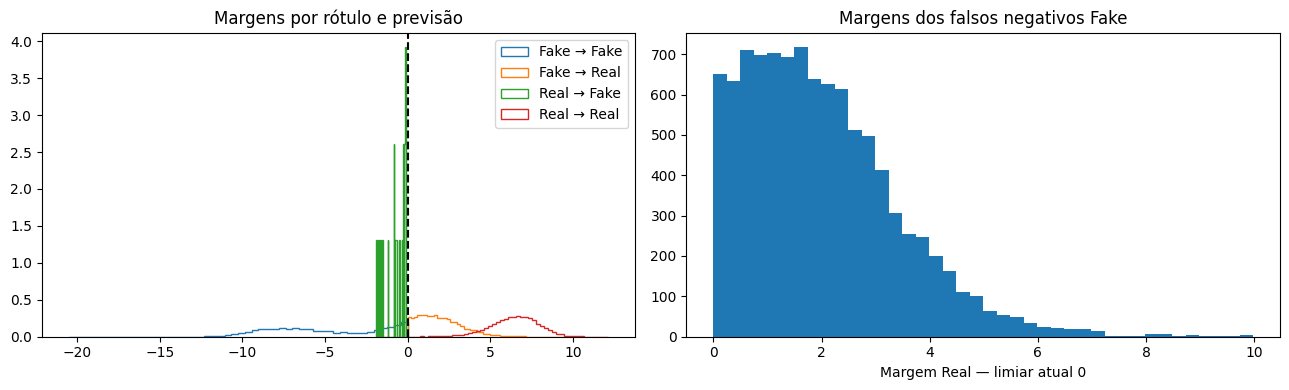

In [9]:
INV_DIR = ROOT / "reports/v2_stacking_texto_autor_exploratorio/avaliacao/fakerecogna_extrativo/investigacao"
INV_DIR.mkdir(parents=True, exist_ok=True)
INV_GRAPH = INV_DIR / "graficos"
INV_GRAPH.mkdir(parents=True, exist_ok=True)
RESULT_DIR = INV_DIR.parent
registro = json.loads((RESULT_DIR / "metricas.json").read_text(encoding="utf-8"))
if sha256_file(ROOT / MODEL_RELATIVE) != registro["model_sha256"]:
    raise ValueError("Modelo diferente do usado nas previsões.")
if sha256_file(ROOT / "data/fakerecogna_extrativo.csv") != registro["data_sha256"]:
    raise ValueError("Dataset diferente do usado nas previsões.")
investigacao = pd.read_csv(RESULT_DIR / "predicoes.csv", keep_default_na=False)
y_inv = validate_labels(investigacao.label).to_numpy()
pred_inv = validate_labels(investigacao.predito).to_numpy()
margens_inv = investigacao.margem_real.to_numpy(dtype=float)
if not np.array_equal(pred_inv, (margens_inv > 0).astype(int)):
    raise ValueError("O sinal das margens não coincide com predict. Investigue o classificador final.")
investigacao["falso_negativo_fake"] = (y_inv == 0) & (pred_inv == 1)
fn_dados = investigacao.loc[investigacao.falso_negativo_fake].copy()
if len(fn_dados) != registro["metrics"]["confusion_matrix"][0][1]:
    raise ValueError("Contagem de falsos negativos incompatível com a avaliação salva.")
quantis = investigacao.groupby(["label", "predito"]).margem_real.quantile(np.asarray([0, .1, .25, .5, .75, .9, .95, 1], dtype=float)).unstack()
quantis.to_csv(INV_DIR / "quantis_margens.csv")
display(quantis)
fn_dados.to_csv(INV_DIR / "falsos_negativos_com_pontuacoes.csv", index=False)
resumo_pontuacoes = {"n_falsos_negativos": len(fn_dados),
    "mediana_margem_fn": float(fn_dados.margem_real.median()),
    "fracao_fn_margem_ate_1": float(fn_dados.margem_real.le(1).mean()),
    "fracao_fn_margem_ate_2": float(fn_dados.margem_real.le(2).mean()),
    "fracao_fn_margem_acima_5": float(fn_dados.margem_real.gt(5).mean()),
    "margens_sao_probabilidades": False}
(INV_DIR / "resumo_pontuacoes.json").write_text(json.dumps(resumo_pontuacoes, indent=2), encoding="utf-8")
cenarios = []
for limiar in [-2.0, -1.0, 0.0, 1.0, 2.0]:
    hipotese_pred = (margens_inv > limiar).astype(int)
    cm = confusion_matrix(y_inv, hipotese_pred, labels=[0, 1])
    cenarios.append({"limiar_margem_real": limiar, "uso": "retrospectivo_nao_selecionado",
        "recall_fake": float(cm[0, 0] / cm[0].sum()), "recall_real": float(cm[1, 1] / cm[1].sum()),
        "fake_como_real": int(cm[0, 1]), "real_como_fake": int(cm[1, 0]),
        "f1_macro": float(f1_score(y_inv, hipotese_pred, average="macro"))})
cenarios = pd.DataFrame(cenarios)
cenarios.to_csv(INV_DIR / "cenarios_limiar_retrospectivos.csv", index=False)
display(cenarios)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for (rotulo, predito), grupo in investigacao.groupby(["label", "predito"]):
    axes[0].hist(grupo.margem_real, bins=50, density=True, histtype="step",
        label=f"{LABEL_NAMES[int(str(rotulo))]} → {LABEL_NAMES[int(str(predito))]}")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("Margens por rótulo e previsão")
axes[0].legend()
axes[1].hist(fn_dados.margem_real, bins=40)
axes[1].set_title("Margens dos falsos negativos Fake")
axes[1].set_xlabel("Margem Real — limiar atual 0")
fig.tight_layout()
fig.savefig(INV_GRAPH / "01_pontuacoes.png", dpi=160)
plt.show()
plt.close(fig)


### Resultado da análise das pontuações

Foram examinados os **9,819 falsos negativos Fake**. A mediana da margem Real é **1.7857**. **27.49%** têm margem até 1; **55.54%**, até 2; **3.37%** têm margem acima de 5.

O erro não está restrito a decisões quase empatadas. Os cenários de limiar exibidos acima são retrospectivos e não escolheram um novo ponto de corte. As margens não são probabilidades calibradas.


## Concentração dos erros por fonte, categoria e período

Extrai o ano apenas do campo Data, sem inferi-lo da notícia ou da URL. Valores sem ano reconhecido permanecem em um grupo próprio. Para fonte, categoria e ano, exporta o suporte total e de Fake, falsos negativos e taxa de falha dentro de Fake. Distingue quantidade de erros de taxa de erro e não atribui causalidade aos grupos.

In [10]:
investigacao["fonte_inv"] = investigacao.URL.map(lambda value: urlsplit(str(value)).hostname or "fonte_desconhecida")
investigacao["categoria_inv"] = investigacao.Categoria.astype(str).str.strip().str.casefold().replace("", "ausente") if "Categoria" in investigacao else "ausente"
if "Data" in investigacao:
    investigacao["ano_inv"] = investigacao.Data.astype(str).str.extract(r"\b((?:19|20)\d{2})\b", expand=False).fillna("ano_nao_identificado")
else:
    investigacao["ano_inv"] = "ano_nao_identificado"
registros_erros_grupos = []
for campo in ["fonte_inv", "categoria_inv", "ano_inv"]:
    for nome, grupo in investigacao.groupby(campo):
        n_fake = len(grupo.loc[grupo.label.eq(0)])
        n_fn = len(grupo.loc[grupo.falso_negativo_fake])
        registros_erros_grupos.append({"campo": campo, "grupo": str(nome), "n": len(grupo), "n_fake": n_fake,
            "n_falsos_negativos": n_fn, "taxa_falha_fake": n_fn / n_fake if n_fake else None,
            "participacao_nos_fn": n_fn / len(fn_dados), "suporte_fake_menor_30": n_fake < 30})
erros_grupos = pd.DataFrame(registros_erros_grupos)
erros_grupos.to_csv(INV_DIR / "concentracao_erros.csv", index=False)
for campo in ["fonte_inv", "categoria_inv", "ano_inv"]:
    display(erros_grupos.loc[erros_grupos.campo.eq(campo)].sort_values("n_falsos_negativos", ascending=False).head(12))
amostras_fn = pd.concat([
    grupo.drop(columns="fonte_inv").sample(n=min(10, len(grupo)), random_state=42)
    for _, grupo in investigacao.loc[investigacao.falso_negativo_fake].groupby("fonte_inv", sort=True)
], axis=0)
amostras_fn.to_csv(INV_DIR / "amostra_fn_por_fonte.csv", index=False)


,campo,grupo,n,n_fake,n_falsos_negativos,taxa_falha_fake,participacao_nos_fn,suporte_fake_menor_30
15,fonte_inv,www.e-farsas.com,3270,3270,2616,0.800000,0.266422,False
6,fonte_inv,lupa.uol.com.br,3133,3133,2330,0.743696,0.237295,False
8,fonte_inv,noticias.uol.com.br,8845,1972,1603,0.812880,0.163255,False
12,fonte_inv,www.aosfatos.org,2656,2656,1528,0.575301,0.155617,False
9,fonte_inv,politica.estadao.com.br,1156,1156,799,0.691176,0.081373,False
10,fonte_inv,projetocomprova.com.br,488,488,329,0.674180,0.033506,False
0,fonte_inv,checamos.afp.com,1138,1138,228,0.200351,0.023220,False
13,fonte_inv,www.boatos.org,6118,6118,216,0.035306,0.021998,False
5,fonte_inv,g1.globo.com,4411,1267,110,0.086819,0.011203,False
16,fonte_inv,www.estadao.com.br,98,98,56,0.571429,0.005703,False


,campo,grupo,n,n_fake,n_falsos_negativos,taxa_falha_fake,participacao_nos_fn,suporte_fake_menor_30
21,categoria_inv,ausente,5716,5716,3357,0.587299,0.341888,False
80,categoria_inv,uol confere,1885,1885,1516,0.804244,0.154395,False
70,categoria_inv,nas redes,2471,2471,1371,0.554836,0.139627,False
49,categoria_inv,falso,930,930,759,0.816129,0.077299,False
30,categoria_inv,conspirações,497,497,411,0.826962,0.041858,False
36,categoria_inv,crimes,356,356,312,0.876404,0.031775,False
75,categoria_inv,política,9478,2817,213,0.075612,0.021693,False
25,categoria_inv,cinema / tv,248,248,200,0.806452,0.020369,False
20,categoria_inv,animais,254,254,184,0.724409,0.018739,False
19,categoria_inv,acidentes,209,209,161,0.770335,0.016397,False


,campo,grupo,n,n_fake,n_falsos_negativos,taxa_falha_fake,participacao_nos_fn,suporte_fake_menor_30
105,ano_inv,2022,4997,4776,1909,0.399707,0.194419,False
103,ano_inv,2020,12465,2476,1501,0.606220,0.152867,False
104,ano_inv,2021,16096,2666,1278,0.479370,0.130156,False
101,ano_inv,2018,2549,2549,1231,0.482934,0.125369,False
102,ano_inv,2019,2357,2336,1103,0.472175,0.112333,False
106,ano_inv,2023,2632,2632,937,0.356003,0.095427,False
100,ano_inv,2017,1591,1591,676,0.424890,0.068846,False
99,ano_inv,2016,782,782,354,0.452685,0.036053,False
97,ano_inv,2014,441,441,219,0.496599,0.022304,False
98,ano_inv,2015,398,398,163,0.409548,0.016600,False


### Resultado da concentração dos erros

#### Fontes

| Grupo | Fake de referência | Fake como Real | Taxa de falha Fake |
| --- | --- | --- | --- |
| www.e-farsas.com | 3270 | 2616 | 80.00% |
| lupa.uol.com.br | 3133 | 2330 | 74.37% |
| noticias.uol.com.br | 1972 | 1603 | 81.29% |
| www.aosfatos.org | 2656 | 1528 | 57.53% |
| politica.estadao.com.br | 1156 | 799 | 69.12% |


#### Categorias

| Grupo | Fake de referência | Fake como Real | Taxa de falha Fake |
| --- | --- | --- | --- |
| ausente | 5716 | 3357 | 58.73% |
| uol confere | 1885 | 1516 | 80.42% |
| nas redes | 2471 | 1371 | 55.48% |
| falso | 930 | 759 | 81.61% |
| conspirações | 497 | 411 | 82.70% |


#### Anos identificados em Data

| Grupo | Fake de referência | Fake como Real | Taxa de falha Fake |
| --- | --- | --- | --- |
| 2022 | 4776 | 1909 | 39.97% |
| 2020 | 2476 | 1501 | 60.62% |
| 2021 | 2666 | 1278 | 47.94% |
| 2018 | 2549 | 1231 | 48.29% |
| 2019 | 2336 | 1103 | 47.22% |


Contagens e taxas devem ser lidas juntas: grupos maiores podem acumular mais erros. As categorias e fontes podem refletir o processo de checagem. O ano foi extraído apenas de Data; a análise não demonstra que o período cause os erros.


## Contribuição de título, notícia e autor — perturbações controladas

Usa uma amostra determinística de até 1.000 registros, preservando a proporção de cada combinação de rótulo e previsão. Com o ensemble congelado, compara a entrada completa com título vazio, notícia vazia e autor ausente. Não é treinamento sem a feature nem uma decomposição causal: retirar texto muda a normalização conjunta do TF-IDF, e autor ausente pode ter sua própria categoria aprendida. A amostra e as margens antes/depois são exportadas.

In [11]:
amostras = []
for (rotulo, predito), grupo in investigacao.groupby(["label", "predito"]):
    n_amostra = max(1, round(1000 * len(grupo) / len(investigacao)))
    amostras.append(grupo.sample(n=min(n_amostra, len(grupo)), random_state=42))
amostra_contrib = pd.concat(amostras).sort_values("id_externo").reset_index(drop=True)
entrada_contrib = amostra_contrib[FEATURE_COLUMNS].copy()
margem_original = model.decision_function(entrada_contrib)
pred_original = model.predict(entrada_contrib)
tabelas_perturbacoes = []
for coluna in FEATURE_COLUMNS:
    entrada_alterada = entrada_contrib.copy()
    entrada_alterada[coluna] = ""
    margem_alterada = model.decision_function(entrada_alterada)
    pred_alterado = model.predict(entrada_alterada)
    tabela = amostra_contrib[["id_externo", "label", "predito", "fonte_inv"]].copy()
    tabela["coluna_esvaziada"] = coluna
    tabela["margem_original"] = margem_original
    tabela["margem_perturbada"] = margem_alterada
    tabela["delta_margem_real"] = margem_alterada - margem_original
    tabela["predicao_perturbada"] = pred_alterado
    tabela["mudou_predicao"] = pred_alterado != pred_original
    tabelas_perturbacoes.append(tabela)
    print("Perturbação concluída:", coluna, flush=True)
perturbacoes = pd.concat(tabelas_perturbacoes, ignore_index=True)
perturbacoes.to_csv(INV_DIR / "contribuicao_por_perturbacao.csv", index=False)
amostra_contrib.to_csv(INV_DIR / "amostra_contribuicao.csv", index=False)
resumo_contrib = cast(pd.DataFrame, perturbacoes.groupby("coluna_esvaziada").agg(n=("id_externo", "size"),
    mudancas=("mudou_predicao", "sum"), delta_mediano=("delta_margem_real", "median")))
resumo_contrib["fracao_mudancas"] = resumo_contrib.mudancas / resumo_contrib.n
resumo_contrib.to_csv(INV_DIR / "resumo_contribuicao.csv")
display(resumo_contrib)


Perturbação concluída: Titulo
Perturbação concluída: Noticia
Perturbação concluída: Autor


,n,mudancas,delta_mediano,fracao_mudancas
coluna_esvaziada,,,,
Autor,1000,226,1.645047,0.226
Noticia,1000,100,-2.241396,0.100
Titulo,1000,53,0.075572,0.053


### Resultado das perturbações de entrada

Na amostra de **1.000 registros**, mantendo o ensemble congelado:

| Coluna esvaziada | Previsões alteradas | Percentual | Delta mediano da margem Real |
| --- | --- | --- | --- |
| Autor | 226 | 22.60% | 1.6450 |
| Noticia | 100 | 10.00% | -2.2414 |
| Titulo | 53 | 5.30% | 0.0756 |


A autoria apresentou maior sensibilidade nesta amostra. Isso não prova seu efeito causal nem equivale a treinar sem autor. Esvaziar título ou notícia altera a composição e a normalização conjunta do TF-IDF; autor ausente pode ter categoria aprendida própria.


## Independência — pares por título e possíveis eventos

As exclusões anteriores cobriram texto, título e URL exatos e similaridade de texto composto. Esta etapa acrescenta similaridade de caracteres entre títulos para encontrar variantes da mesma notícia que podem escapar do primeiro filtro. Exporta o par mais próximo e candidatos com cosseno ≥ 0,85 para consulta à fonte. Não exclui novos registros nem recalcula métricas após observar os resultados. Similaridade não comprova mesmo evento; ausência de coincidência também não certifica independência.

In [12]:
origem_inv = pd.read_excel(ROOT / "data/FakeRecogna.xlsx").fillna("").reset_index(drop=True)
validate_schema(origem_inv, ["Titulo", "Noticia", "URL", "Classe"], context="auditoria de eventos")
hashing_titulos = HashingVectorizer(n_features=2**18, alternate_sign=False, norm="l2",
    analyzer="char_wb", ngram_range=(3, 5), preprocessor=normalize_text, lowercase=False)
matriz_titulos_origem = csr_matrix(hashing_titulos.transform(origem_inv.Titulo))
vizinhos_titulos = NearestNeighbors(n_neighbors=1, metric="cosine", algorithm="brute", n_jobs=1).fit(matriz_titulos_origem)
sim_titulos = np.zeros(len(investigacao))
idx_titulos = np.zeros(len(investigacao), dtype=int)
for inicio in range(0, len(investigacao), 256):
    fim = min(inicio + 256, len(investigacao))
    lote = csr_matrix(hashing_titulos.transform(investigacao.Titulo.iloc[inicio:fim]))
    distancias, indices = vizinhos_titulos.kneighbors(lote)
    sim_titulos[inicio:fim] = 1 - np.asarray(distancias)[:, 0]
    idx_titulos[inicio:fim] = np.asarray(indices)[:, 0]
    if inicio % 8192 == 0 or fim == len(investigacao):
        print(f"Auditoria de títulos: {fim}/{len(investigacao)}", flush=True)
pares_eventos = investigacao[["id_externo", "Titulo", "URL", "label", "predito", "falso_negativo_fake"]].copy()
pares_eventos["similaridade_titulo"] = sim_titulos
pares_eventos["id_original_referencia"] = idx_titulos
pares_eventos["titulo_referencia"] = origem_inv.Titulo.iloc[idx_titulos].to_numpy()
pares_eventos["url_referencia"] = origem_inv.URL.iloc[idx_titulos].to_numpy()
pares_eventos["particao_referencia"] = np.where(np.isin(idx_titulos, train.id_original.to_numpy()), "treino_v2",
    np.where(np.isin(idx_titulos, holdout.id_original.to_numpy()), "holdout_v2", "original_fora_particoes"))
pares_eventos["candidato_mesmo_evento"] = pares_eventos.similaridade_titulo.ge(.85)
pares_eventos.to_csv(INV_DIR / "pares_titulos_todos.csv", index=False)
pares_eventos.loc[pares_eventos.candidato_mesmo_evento].sort_values("similaridade_titulo", ascending=False).to_csv(
    INV_DIR / "candidatos_eventos_compartilhados.csv", index=False)
display(pares_eventos.loc[pares_eventos.candidato_mesmo_evento].sort_values("similaridade_titulo", ascending=False).head(20))


Auditoria de títulos: 256/46229
Auditoria de títulos: 8448/46229
Auditoria de títulos: 16640/46229
Auditoria de títulos: 24832/46229
Auditoria de títulos: 33024/46229
Auditoria de títulos: 41216/46229
Auditoria de títulos: 46229/46229


,id_externo,Titulo,URL,label,predito,falso_negativo_fake,similaridade_titulo,id_original_referencia,titulo_referencia,url_referencia,particao_referencia,candidato_mesmo_evento
15870,18096,"Taxista procura Fernanda da Silva Lisboa, que ...",https://www.boatos.org/brasil/taxista-fernanda...,0,0,False,1.000000,9746,"\n\nTaxista procura Fernanda da Silva Lisboa, ...",https://www.boatos.org/brasil/taxista-procura-...,treino_v2,True
35644,40684,\n O meme que relaciona preço do gás com salá...,https://checamos.afp.com//http%253A%252F%252Fd...,0,0,False,1.000000,8607,\n É enganoso o meme que relaciona preço do g...,https://checamos.afp.com//e-enganoso-o-meme-qu...,treino_v2,True
3939,4487,Brasil aplicou ao menos uma dose de vacina em ...,https://g1.globo.com/bemestar/vacina/noticia/2...,1,1,False,0.997957,8420,Brasil aplicou ao menos uma dose de vacina em ...,https://g1.globo.com/bemestar/vacina/noticia/2...,treino_v2,True
19248,21913,Estudo da USP analisa eficácia da colchicina c...,https://politica.estadao.com.br/blogs/estadao-...,0,0,False,0.997639,5236,Estudo da USP analisa eficácia da colchicina c...,https://projetocomprova.com.br/publicações/est...,treino_v2,True
25938,29604,É falso que China tenha doado 60 helicópteros ...,https://politica.estadao.com.br/blogs/estadao-...,0,1,True,0.997323,1258,É falso que a China tenha doado 60 helicóptero...,https://projetocomprova.com.br/publicações/e-f...,holdout_v2,True
37354,42622,É falso que Bolsonaro anunciou o fim das cotas...,https://politica.estadao.com.br/blogs/estadao-...,0,0,False,0.996870,1039,É falso que Bolsonaro anunciou fim das cotas n...,https://noticias.uol.com.br/comprova/ultimas-n...,treino_v2,True
10574,12019,Holanda é o último país da União Europeia a in...,https://g1.globo.com/mundo/noticia/2021/01/06/...,1,1,False,0.996850,627,Holanda é último país da União Europeia a inic...,https://noticias.uol.com.br/saude/ultimas-noti...,holdout_v2,True
23113,26362,É falso que o Exército tenha apreendido madeir...,https://politica.estadao.com.br/blogs/estadao-...,0,0,False,0.996546,1915,É falso que Exército tenha apreendido madeira ...,https://projetocomprova.com.br/publicações/e-f...,treino_v2,True
8879,10093,Post mostra imagens de outras estradas para af...,https://politica.estadao.com.br/blogs/estadao-...,0,1,True,0.995360,10197,Post mostra imagens de outras estradas para af...,https://projetocomprova.com.br/publicações/pos...,treino_v2,True
38199,43573,Brasil aplicou ao menos uma dose de vacina em ...,https://g1.globo.com/bemestar/vacina/noticia/2...,1,1,False,0.995305,2872,Brasil aplicou ao menos uma dose de vacina em ...,https://g1.globo.com/bemestar/vacina/noticia/2...,treino_v2,True


### Resultado da auditoria adicional de independência

Foram encontrados **576 pares** com similaridade de título ≥ 0,85. Destes, **471** apontam para registros de treinamento da v2.

Esses pares são candidatos a duplicatas ou notícias do mesmo evento, não confirmações. Os títulos e URLs são apresentados na tabela da célula anterior e exportados para consulta. A independência externa continua **não certificada**. As métricas e exclusões anteriores não foram alteradas após observar o teste.


## Comparação dos modelos congelados com o stacking

Regressão Logística, LinearSVC e Random Forest são as bases já ajustadas dentro do ensemble da v2. Cada base recebe as mesmas entradas e utiliza seu próprio TF-IDF e codificação de autor. MultinomialNB não integra o stacking; será avaliado com o artefato congelado da v1, após conferir colunas, classes e proveniência. Seus resultados são complementares, pois a v1 tem outro split e TF-IDF com outro vocabulário/ngramas. Não é uma comparação controlada apenas do algoritmo. Nenhum fit é realizado e nenhum vencedor substituirá o ensemble por ter melhor resultado neste teste observado.

In [13]:
classificadores_congelados = {"Stacking v2": model}
stacking_inv = cast(StackingClassifier, model.named_steps["clf"])
for nome, classificador in stacking_inv.named_estimators_.items():
    classificadores_congelados[f"{nome} v2"] = classificador
NB_PATH = ROOT / "models/v1_texto_autor_exploratorio/benchmark_nb.joblib"
nb_status = "artefato_ausente"
nb_hash = None
if NB_PATH.is_file():
    sys.path.insert(0, str(ROOT / "notebooks/v1_baseline"))
    import baseline_features
    nb_hash = sha256_file(NB_PATH)
    nb_bundle = joblib.load(NB_PATH)
    if not isinstance(nb_bundle, dict) or nb_bundle.get("feature_columns") != FEATURE_COLUMNS or nb_bundle.get("label_names") != LABEL_NAMES:
        raise ValueError("MultinomialNB da v1 possui contrato incompatível.")
    if nb_bundle.get("review", {}).get("raw_sha256") != sha256_file(ROOT / "data/FakeRecogna.xlsx"):
        raise ValueError("A proveniência do MultinomialNB não corresponde ao corpus auditado.")
    nb_pipeline = nb_bundle["pipeline"]
    if not isinstance(nb_pipeline.named_steps["clf"], MultinomialNB) or list(nb_pipeline.classes_) != [0, 1]:
        raise ValueError("Artefato NB não contém o classificador e classes esperados.")
    nb_status = "v1_comparacao_complementar_protocolo_distinto"
    classificadores_congelados["MultinomialNB v1 — complementar"] = nb_pipeline
resultados_individuais = []
for nome, classificador in classificadores_congelados.items():
    if nome == "Stacking v2":
        previsto = pred_inv
    else:
        previsto = np.asarray(classificador.predict(investigacao[FEATURE_COLUMNS]), dtype=int)
    cm = confusion_matrix(y_inv, previsto, labels=[0, 1])
    resultados_individuais.append({"modelo": nome, "n": len(investigacao),
        "accuracy": float(accuracy_score(y_inv, previsto)), "f1_macro": float(f1_score(y_inv, previsto, average="macro")),
        "recall_fake": float(cm[0, 0] / cm[0].sum()), "recall_real": float(cm[1, 1] / cm[1].sum()),
        "fake_como_real": int(cm[0, 1]), "real_como_fake": int(cm[1, 0]),
        "protocolo": "v1_distinto" if nome.startswith("MultinomialNB") else "v2_mesmas_bases_e_treino"})
    predicoes_individuais = investigacao[["id_externo", "label"]].copy()
    predicoes_individuais["predito"] = previsto
    arquivo_nome = re.sub(r"[^a-z0-9]+", "_", nome.casefold()).strip("_")
    predicoes_individuais.to_csv(INV_DIR / f"previsoes_{arquivo_nome}.csv", index=False)
    print("Modelo avaliado:", nome, flush=True)
comparacao_congelados = pd.DataFrame(resultados_individuais)
comparacao_congelados.to_csv(INV_DIR / "comparacao_modelos_congelados.csv", index=False)
if sha256_file(ROOT / MODEL_RELATIVE) != registro["model_sha256"] or (nb_hash is not None and sha256_file(NB_PATH) != nb_hash):
    raise RuntimeError("Artefato alterado durante a investigação.")
(INV_DIR / "status_nb.json").write_text(json.dumps({"status": nb_status, "sha256": nb_hash,
    "review": nb_bundle.get("review", {}) if nb_hash is not None else {}}, indent=2, default=str), encoding="utf-8")
display(comparacao_congelados)


Modelo avaliado: Stacking v2
Modelo avaliado: regressao_logistica v2
Modelo avaliado: random_forest v2
Modelo avaliado: svc v2
Modelo avaliado: MultinomialNB v1 — complementar


,modelo,n,accuracy,f1_macro,recall_fake,recall_real,fake_como_real,real_como_fake,protocolo
0,Stacking v2,46229,0.787147,0.767536,0.539014,0.999158,9819,21,v2_mesmas_bases_e_treino
1,regressao_logistica v2,46229,0.714011,0.670399,0.380094,0.999318,13204,17,v2_mesmas_bases_e_treino
2,random_forest v2,46229,0.870817,0.865140,0.722347,0.997673,5914,58,v2_mesmas_bases_e_treino
3,svc v2,46229,0.738497,0.704571,0.433662,0.998957,12063,26,v2_mesmas_bases_e_treino
4,MultinomialNB v1 — complementar,46229,0.850873,0.842886,0.678685,0.997994,6844,50,v1_distinto


### Gráfico — comparação dos modelos congelados com o Stacking

Compara F1-macro, recall FAKE e recall REAL no mesmo subconjunto avaliado. Destaca o Stacking em laranja e apresenta os valores de cada modelo. Carrega a tabela de métricas salva, sem repetir as previsões ou treinar modelos. O MultinomialNB da v1 possui protocolo distinto e sua comparação é complementar.


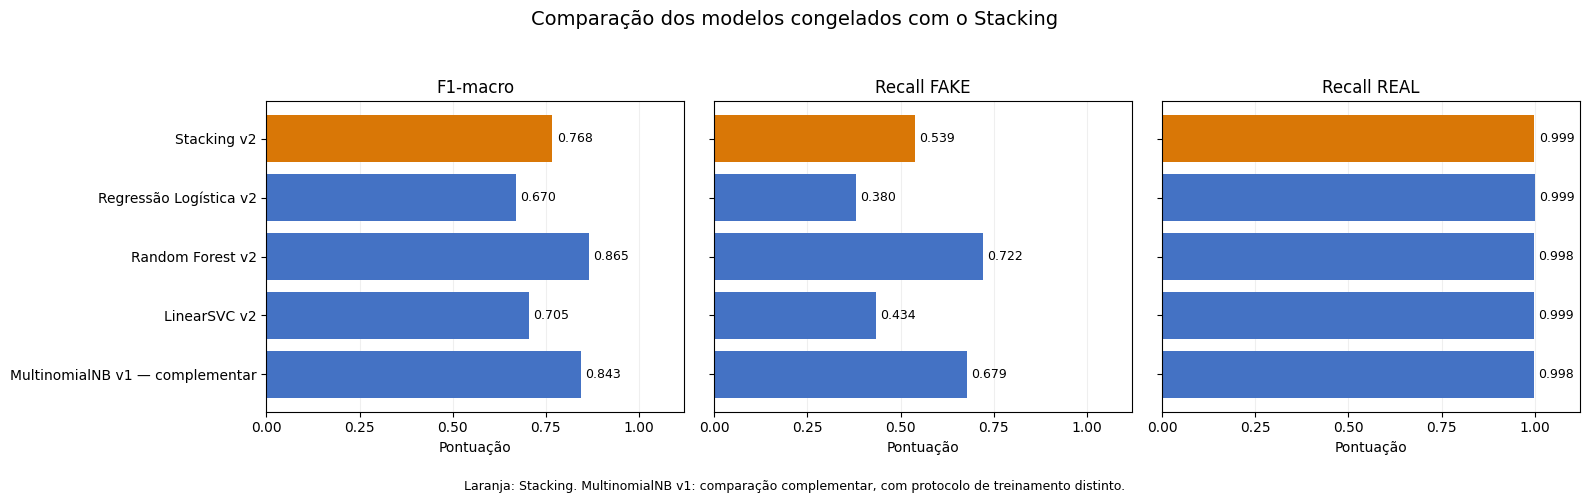

In [14]:
comparacao_congelados = pd.read_csv(ROOT / "reports/v2_stacking_texto_autor_exploratorio/avaliacao/fakerecogna_extrativo/investigacao/comparacao_modelos_congelados.csv")
nomes = comparacao_congelados.modelo.str.replace("regressao_logistica", "Regressão Logística", regex=False).str.replace("random_forest", "Random Forest", regex=False).str.replace("svc v2", "LinearSVC v2", regex=False)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, metrica, titulo in zip(axes, ["f1_macro", "recall_fake", "recall_real"],
                             ["F1-macro", "Recall FAKE", "Recall REAL"]):
    valores = comparacao_congelados[metrica].to_numpy(dtype=float)
    cores = ["#d97706" if nome == "Stacking v2" else "#4472c4" for nome in comparacao_congelados.modelo]
    barras = ax.barh(np.arange(len(nomes)), valores, color=cores)
    ax.bar_label(barras, labels=[f"{valor:.3f}" for valor in valores], padding=3, fontsize=9)
    ax.set_xlim(0, 1.12)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_title(titulo)
    ax.set_xlabel("Pontuação")
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
axes[0].set_yticks(np.arange(len(nomes)), nomes.to_list())
axes[0].invert_yaxis()
fig.suptitle("Comparação dos modelos congelados com o Stacking", fontsize=14)
fig.text(0.5, 0.02, "Laranja: Stacking. MultinomialNB v1: comparação complementar, com protocolo de treinamento distinto.", ha="center", fontsize=9)
fig.tight_layout(rect=(0, 0.06, 1, 0.94))
pasta_graficos = ROOT / "reports/v2_stacking_texto_autor_exploratorio/avaliacao/fakerecogna_extrativo/investigacao/graficos"
pasta_graficos.mkdir(parents=True, exist_ok=True)
fig.savefig(pasta_graficos / "02_comparacao_congelados.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)


### Resultado da comparação dos modelos

| Modelo congelado | F1-macro | Recall Fake | Fake como Real |
| --- | --- | --- | --- |
| Stacking v2 | 0.7675 | 53.90% | 9819 |
| regressao_logistica v2 | 0.6704 | 38.01% | 13204 |
| random_forest v2 | 0.8651 | 72.23% | 5914 |
| svc v2 | 0.7046 | 43.37% | 12063 |
| MultinomialNB v1 — complementar | 0.8429 | 67.87% | 6844 |


A Random Forest isolada recuperou mais Fake que o stacking neste conjunto. Nenhum modelo foi substituído. O MultinomialNB pertence à v1, com outro split e outro TF-IDF; sua comparação é complementar e não isola o algoritmo. Estes resultados observados não escolhem um campeão externo independente.


## Auditoria do protocolo de treinamento OOF

Reconstrói as dobras externas e internas do 02, confere o mapa e as previsões OOF e calcula sobreposições de IDs, textos, grupos de similaridade, fontes e autores. Não ajusta modelos. A resposta é incorporada à síntese logo depois de Modelos.


In [15]:
PROTO_DIR = ROOT / "reports/v2_stacking_texto_autor_exploratorio/avaliacao/fakerecogna_extrativo/investigacao"
stack_proto = cast(StackingClassifier, model.named_steps["clf"])
parametros_proto = stack_proto.get_params(deep=False)
cv_interno_proto = parametros_proto["cv"]
if not isinstance(cv_interno_proto, StratifiedKFold) or cv_interno_proto.get_n_splits() != 5 or parametros_proto["passthrough"]:
    raise ValueError("O artefato não corresponde ao stacking com cinco dobras internas esperado.")
mapa_proto = pd.read_csv(ROOT / "reports/v2_stacking_texto_autor_exploratorio/mapa_dobras_cv.csv")
oof_proto = pd.read_csv(ROOT / "reports/v2_stacking_texto_autor_exploratorio/stacking/predicoes_oof.csv")
cv_proto = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
frame_proto = train.reset_index(drop=True).copy()
frame_proto["texto_normalizado_proto"] = frame_proto.texto.map(normalize_text)
frame_proto["autor_proto"] = prepare_authors(frame_proto).ravel()
y_proto = validate_labels(frame_proto.label)
atribuicoes_proto = np.full(len(frame_proto), -1, dtype=int)
visitas_proto = np.zeros(len(frame_proto), dtype=int)
registros_proto = []
def sobreposicoes_proto(esquerda: pd.DataFrame, direita: pd.DataFrame) -> dict[str, int | None]:
    resultado: dict[str, int | None] = {"ids_compartilhados": len(set(esquerda.id_original) & set(direita.id_original)),
        "textos_exatos_compartilhados": len(set(esquerda.texto_normalizado_proto) & set(direita.texto_normalizado_proto)),
        "autores_compartilhados": len((set(esquerda.autor_proto) & set(direita.autor_proto)) - {"autor_desconhecido"})}
    for coluna, nome in [("grupo_similaridade", "grupos_similares_compartilhados"), ("fonte_auditoria", "fontes_compartilhadas")]:
        resultado[nome] = len((set(esquerda[coluna]) & set(direita[coluna])) - {""}) if coluna in esquerda and coluna in direita else None
    return resultado
for dobra, (idx_fit, idx_val) in enumerate(cv_proto.split(frame_proto[FEATURE_COLUMNS], y_proto), start=1):
    atribuicoes_proto[idx_val] = dobra
    visitas_proto[idx_val] += 1
    treino_dobra, validacao_dobra = frame_proto.iloc[idx_fit], frame_proto.iloc[idx_val]
    registros_proto.append({"nivel": "externa_oof", "dobra": dobra, "dobra_interna": 0,
        "n_treino": len(idx_fit), "n_validacao": len(idx_val), **sobreposicoes_proto(treino_dobra, validacao_dobra)})
    visitas_internas = np.zeros(len(idx_fit), dtype=int)
    for interna, (fit_local, val_local) in enumerate(cv_interno_proto.split(treino_dobra[FEATURE_COLUMNS], y_proto.iloc[idx_fit]), start=1):
        visitas_internas[val_local] += 1
        registros_proto.append({"nivel": "interna_meta_na_dobra_externa", "dobra": dobra, "dobra_interna": interna,
            "n_treino": len(fit_local), "n_validacao": len(val_local),
            **sobreposicoes_proto(treino_dobra.iloc[fit_local], treino_dobra.iloc[val_local])})
    if not np.all(visitas_internas == 1):
        raise ValueError("Cobertura das dobras internas inválida.")
for interna, (idx_fit, idx_val) in enumerate(cv_interno_proto.split(frame_proto[FEATURE_COLUMNS], y_proto), start=1):
    registros_proto.append({"nivel": "interna_meta_ajuste_final", "dobra": 0, "dobra_interna": interna,
        "n_treino": len(idx_fit), "n_validacao": len(idx_val),
        **sobreposicoes_proto(frame_proto.iloc[idx_fit], frame_proto.iloc[idx_val])})
if not np.all(visitas_proto == 1):
    raise ValueError("Cobertura OOF externa inválida.")
if mapa_proto.id_original.duplicated().any() or oof_proto.id_original.duplicated().any():
    raise ValueError("IDs repetidos no mapa ou nas previsões OOF.")
mapa_por_id = mapa_proto.set_index("id_original").dobra_validacao
if not set(frame_proto.id_original).issubset(set(mapa_por_id.index)) or len(mapa_proto) != len(frame_proto):
    raise ValueError("Mapa não cobre exatamente o treino.")
if not np.array_equal(mapa_por_id.loc[frame_proto.id_original].to_numpy(), atribuicoes_proto):
    raise ValueError("Dobras reconstruídas divergem do mapa da execução.")
if set(oof_proto.id_original) != set(frame_proto.id_original) or not np.array_equal(
    oof_proto.set_index("id_original").loc[frame_proto.id_original, "dobra"].to_numpy(), atribuicoes_proto):
    raise ValueError("Previsões OOF não correspondem às dobras reconstruídas.")
auditoria_proto = pd.DataFrame(registros_proto)
auditoria_proto.to_csv(PROTO_DIR / "auditoria_dobras_treinamento.csv", index=False)
holdout_proto = holdout.copy()
holdout_proto["texto_normalizado_proto"] = holdout_proto.texto.map(normalize_text)
holdout_proto["autor_proto"] = prepare_authors(holdout_proto).ravel()
separacao_holdout = sobreposicoes_proto(frame_proto, holdout_proto)
resumo_proto = {"n_treino": len(frame_proto), "n_holdout": len(holdout),
    "oof_externa_por_registro": {"min": int(visitas_proto.min()), "max": int(visitas_proto.max())},
    "dobras_externas": 5, "dobras_internas_por_externa": 5, "comparacoes_auditadas": len(auditoria_proto),
    "ids_compartilhados_dobras": int(auditoria_proto.ids_compartilhados.sum()),
    "textos_compartilhados_dobras": int(auditoria_proto.textos_exatos_compartilhados.sum()),
    "comparacoes_com_grupos_similares": len(auditoria_proto.loc[auditoria_proto.grupos_similares_compartilhados.gt(0)]),
    "comparacoes_com_fontes_compartilhadas": len(auditoria_proto.loc[auditoria_proto.fontes_compartilhadas.gt(0)]),
    "comparacoes_com_autores_compartilhados": len(auditoria_proto.loc[auditoria_proto.autores_compartilhados.gt(0)]),
    "treino_vs_holdout": separacao_holdout, "novo_treinamento_executado": False}
(PROTO_DIR / "auditoria_protocolo.json").write_text(json.dumps(resumo_proto, indent=2, ensure_ascii=False), encoding="utf-8")
tabela_protocolo = "| Nível | Comparações | Com IDs em comum | Com texto exato em comum | Com grupos similares em comum | Com fontes em comum | Com autores em comum |\n|---|---:|---:|---:|---:|---:|---:|\n"
for nivel, grupo in auditoria_proto.groupby("nivel", sort=False):
    valores = [len(grupo), len(grupo.loc[grupo.ids_compartilhados.gt(0)]),
        len(grupo.loc[grupo.textos_exatos_compartilhados.gt(0)]),
        len(grupo.loc[grupo.grupos_similares_compartilhados.gt(0)]),
        len(grupo.loc[grupo.fontes_compartilhadas.gt(0)]), len(grupo.loc[grupo.autores_compartilhados.gt(0)])]
    tabela_protocolo += "| " + str(nivel) + " | " + " | ".join(str(v) for v in valores) + " |\n"
texto_protocolo = f"""### Protocolo de treinamento: o Stacking foi treinado com previsões out-of-fold e sem vazamento entre treino e validação?

**Sim quanto ao mecanismo OOF; não é possível afirmar ausência total de vazamento ou dependência.**
O notebook 02 usa StackingClassifier com cinco dobras internas para gerar as previsões que treinam a Regressão Logística final. Cada base contém seu próprio pipeline de PLN, TF-IDF e autor: o vocabulário e o IDF são ajustados dentro das dobras, não antes do stacking. passthrough=False evita acrescentar as features originais à entrada do meta-modelo.

A avaliação interna usa outras cinco dobras externas, clonando e ajustando o stacking somente no treino de cada dobra. Foram conferidas **{len(oof_proto)} previsões OOF**, com **uma previsão por registro**, e o mapa salvo coincide com as dobras reconstruídas.

{tabela_protocolo}

Foram auditadas {len(auditoria_proto)} separações: cinco externas, 25 internas das externas e cinco internas do ajuste final. As quantidades de grupos na tabela contam separações com sobreposição, não eventos únicos.
Não há IDs ou textos normalizados exatos compartilhados nas dobras auditadas. Entretanto, **{resumo_proto['comparacoes_com_grupos_similares']} separações têm grupos de similaridade compartilhados**, **{resumo_proto['comparacoes_com_fontes_compartilhadas']} têm fontes compartilhadas** e **{resumo_proto['comparacoes_com_autores_compartilhados']} têm autores compartilhados**. As dobras são estratificadas por classe, não por fonte/evento. Isso permite dependência entre exemplos e possível inflação das métricas; compartilhar autor ou fonte não prova, isoladamente, vazamento direto de rótulo.

No treino versus holdout, há {separacao_holdout['ids_compartilhados']} IDs, {separacao_holdout['textos_exatos_compartilhados']} textos exatos e {separacao_holdout['grupos_similares_compartilhados']} grupos de similaridade compartilhados. A ausência desses cruzamentos não exclui eventos não detectados nem pistas editoriais nos textos.

A verificação reconstrói índices e cruza artefatos persistidos, sem treinar novamente. As previsões internas usadas pelo meta-modelo não foram salvas individualmente; o uso de OOF é sustentado pela configuração do artefato e pelo mecanismo do código, não por uma inspeção de um arquivo dessas previsões internas.
**Conclusão:** o protocolo OOF e o encaixe das features evitam contaminação direta por linhas e ajuste global do TF-IDF nas dobras. Ainda não garantem independência de fontes, autores, eventos ou textos de checagem. A ausência total de data leakage não está demonstrada.
"""
display(Markdown(texto_protocolo))


### Protocolo de treinamento: o Stacking foi treinado com previsões out-of-fold e sem vazamento entre treino e validação?

**Sim quanto ao mecanismo OOF; não é possível afirmar ausência total de vazamento ou dependência.**
O notebook 02 usa StackingClassifier com cinco dobras internas para gerar as previsões que treinam a Regressão Logística final. Cada base contém seu próprio pipeline de PLN, TF-IDF e autor: o vocabulário e o IDF são ajustados dentro das dobras, não antes do stacking. passthrough=False evita acrescentar as features originais à entrada do meta-modelo.

A avaliação interna usa outras cinco dobras externas, clonando e ajustando o stacking somente no treino de cada dobra. Foram conferidas **9518 previsões OOF**, com **uma previsão por registro**, e o mapa salvo coincide com as dobras reconstruídas.

| Nível | Comparações | Com IDs em comum | Com texto exato em comum | Com grupos similares em comum | Com fontes em comum | Com autores em comum |
|---|---:|---:|---:|---:|---:|---:|
| externa_oof | 5 | 0 | 0 | 5 | 5 | 5 |
| interna_meta_na_dobra_externa | 25 | 0 | 0 | 25 | 25 | 25 |
| interna_meta_ajuste_final | 5 | 0 | 0 | 5 | 5 | 5 |


Foram auditadas 35 separações: cinco externas, 25 internas das externas e cinco internas do ajuste final. As quantidades de grupos na tabela contam separações com sobreposição, não eventos únicos.
Não há IDs ou textos normalizados exatos compartilhados nas dobras auditadas. Entretanto, **35 separações têm grupos de similaridade compartilhados**, **35 têm fontes compartilhadas** e **35 têm autores compartilhados**. As dobras são estratificadas por classe, não por fonte/evento. Isso permite dependência entre exemplos e possível inflação das métricas; compartilhar autor ou fonte não prova, isoladamente, vazamento direto de rótulo.

No treino versus holdout, há 0 IDs, 0 textos exatos e 0 grupos de similaridade compartilhados. A ausência desses cruzamentos não exclui eventos não detectados nem pistas editoriais nos textos.

A verificação reconstrói índices e cruza artefatos persistidos, sem treinar novamente. As previsões internas usadas pelo meta-modelo não foram salvas individualmente; o uso de OOF é sustentado pela configuração do artefato e pelo mecanismo do código, não por uma inspeção de um arquivo dessas previsões internas.
**Conclusão:** o protocolo OOF e o encaixe das features evitam contaminação direta por linhas e ajuste global do TF-IDF nas dobras. Ainda não garantem independência de fontes, autores, eventos ou textos de checagem. A ausência total de data leakage não está demonstrada.


## Síntese da investigação e limites

A célula abaixo apresenta a síntese em Markdown diretamente no notebook. Não escolhe outro limiar, não retreina classificadores e não altera a seleção usada nas métricas. Os candidatos a eventos compartilhados exigem consulta à fonte; o MultinomialNB da v1 é uma comparação complementar.


In [16]:
n_candidatos = len(pares_eventos.loc[pares_eventos.candidato_mesmo_evento])
n_candidatos_treino = len(pares_eventos.loc[pares_eventos.candidato_mesmo_evento & pares_eventos.particao_referencia.eq("treino_v2")])
tabela_modelos = "| Modelo | F1-macro | Recall Fake | Fake como Real |\n|---|---:|---:|---:|\n"
for linha in comparacao_congelados.itertuples(index=False):
    tabela_modelos += f"| {linha.modelo} | {linha.f1_macro:.4f} | {100 * float(str(linha.recall_fake)):.2f}% | {linha.fake_como_real} |\n"
tabela_contrib = "| Coluna esvaziada | Fração de previsões alteradas | Delta mediano da margem Real |\n|---|---:|---:|\n"
contrib_relatorio = cast(pd.DataFrame, resumo_contrib).reset_index()
for registro_contrib in contrib_relatorio.to_dict(orient="records"):
    tabela_contrib += f"| {registro_contrib['coluna_esvaziada']} | {100 * float(str(registro_contrib['fracao_mudancas'])):.2f}% | {float(str(registro_contrib['delta_mediano'])):.4f} |\n"
top_anos = erros_grupos.loc[erros_grupos.campo.eq("ano_inv")].sort_values("n_falsos_negativos", ascending=False).head(5)
tabela_anos = "| Ano em Data | Fake no grupo | Falsos negativos Fake | Taxa de falha em Fake |\n|---|---:|---:|---:|\n"
for linha in top_anos.itertuples(index=False):
    tabela_anos += f"| {linha.grupo} | {linha.n_fake} | {linha.n_falsos_negativos} | {100 * float(str(linha.taxa_falha_fake)):.2f}% |\n"
relatorio_inv = f"""# Investigação de pontuações, features, independência e modelos

Foram examinadas todas as {len(fn_dados)} notícias rotuladas Fake e previstas Real.
Mediana da margem Real nesses erros: {resumo_pontuacoes['mediana_margem_fn']:.4f}.
Até margem 1: {100 * resumo_pontuacoes['fracao_fn_margem_ate_1']:.2f}%; até margem 2: {100 * resumo_pontuacoes['fracao_fn_margem_ate_2']:.2f}%.
Acima de margem 5: {100 * resumo_pontuacoes['fracao_fn_margem_acima_5']:.2f}%.
O sinal da margem foi conferido contra predict. Margens não são probabilidades calibradas.

## Fontes, categorias e período

concentracao_erros.csv apresenta suporte de Fake, falsos negativos e taxas por fonte, categoria e ano extraído de Data.
{tabela_anos}

Datas não interpretadas permanecem explícitas. As taxas não demonstram causalidade e os grupos possuem diferentes conteúdos e autores.
A amostra de exemplos por fonte está em amostra_fn_por_fonte.csv, sem revisão semântica integral das fontes.

## Título, notícia e autor

A análise de perturbação usa {len(amostra_contrib)} exemplos determinísticos distribuídos por rótulo e resultado.
Consulte resumo_contribuicao.csv e contribuicao_por_perturbacao.csv para mudanças de classe e margem ao esvaziar cada coluna.
Isto mede sensibilidade da entrada com o modelo congelado, não o efeito causal de treinar sem a feature.
{tabela_contrib}

Título e notícia são vetorizados conjuntamente; o autor ausente pode ter codificação aprendida própria.

## Independência

A triagem adicional encontrou {n_candidatos} pares com similaridade de título ≥ 0,85, dos quais {n_candidatos_treino} apontam para registros do treino v2.
São candidatos a duplicata/mesmo evento, não confirmações. Os pares, textos e URLs estão exportados para consulta.
As exclusões e métricas anteriores não foram alteradas. Uma revisão posterior deste conjunto já observado será exploratória.
O corpus derivado não pode ser certificado como independente apenas por filtros automáticos.

## Modelos

comparacao_modelos_congelados.csv compara stacking com suas bases v2 nas mesmas entradas.

{tabela_modelos}

Random Forest obtém F1-macro e recall Fake maiores que o stacking neste conjunto observado. Esse achado não escolhe um novo campeão nem demonstra superioridade em um teste independente.
Status MultinomialNB: {nb_status}. Se disponível, seu artefato v1 utiliza outro split e TF-IDF; não isola a diferença do algoritmo.
Não houve ajuste de classificador, novo vocabulário ou substituição de modelo.

{texto_protocolo}

## Limiar e próximos passos

cenarios_limiar_retrospectivos.csv descreve a troca entre falsos negativos Fake e falsos positivos Fake em cinco limiares.
Nenhum limiar foi selecionado. Fazer calibração ou escolher um limiar exige validação própria e confirmação em outro teste independente ainda não observado.
Priorizar consulta às fontes dos pares e erros; confirmar a unidade rotulada (alegação ou reportagem de checagem) antes de atribuir a discrepância ao modelo.

## Conclusão final do diagnóstico

**O Stacking Ensemble não está superando todos os seus modelos individuais na validação externa.** Nesta avaliação, a Random Forest da v2 apresentou F1-macro de 0,8651 e recall Fake de 72,23%, superiores aos do stacking: 0,7675 e 53,90%, respectivamente. O resultado refere-se ao corpus extrativo avaliado, cuja independência externa não foi certificada; nenhum modelo foi substituído com base neste teste.

"""
display(Markdown(relatorio_inv))


# Investigação de pontuações, features, independência e modelos

Foram examinadas todas as 9819 notícias rotuladas Fake e previstas Real.
Mediana da margem Real nesses erros: 1.7857.
Até margem 1: 27.49%; até margem 2: 55.54%.
Acima de margem 5: 3.37%.
O sinal da margem foi conferido contra predict. Margens não são probabilidades calibradas.

## Fontes, categorias e período

concentracao_erros.csv apresenta suporte de Fake, falsos negativos e taxas por fonte, categoria e ano extraído de Data.
| Ano em Data | Fake no grupo | Falsos negativos Fake | Taxa de falha em Fake |
|---|---:|---:|---:|
| 2022 | 4776 | 1909 | 39.97% |
| 2020 | 2476 | 1501 | 60.62% |
| 2021 | 2666 | 1278 | 47.94% |
| 2018 | 2549 | 1231 | 48.29% |
| 2019 | 2336 | 1103 | 47.22% |


Datas não interpretadas permanecem explícitas. As taxas não demonstram causalidade e os grupos possuem diferentes conteúdos e autores.
A amostra de exemplos por fonte está em amostra_fn_por_fonte.csv, sem revisão semântica integral das fontes.

## Título, notícia e autor

A análise de perturbação usa 1000 exemplos determinísticos distribuídos por rótulo e resultado.
Consulte resumo_contribuicao.csv e contribuicao_por_perturbacao.csv para mudanças de classe e margem ao esvaziar cada coluna.
Isto mede sensibilidade da entrada com o modelo congelado, não o efeito causal de treinar sem a feature.
| Coluna esvaziada | Fração de previsões alteradas | Delta mediano da margem Real |
|---|---:|---:|
| Autor | 22.60% | 1.6450 |
| Noticia | 10.00% | -2.2414 |
| Titulo | 5.30% | 0.0756 |


Título e notícia são vetorizados conjuntamente; o autor ausente pode ter codificação aprendida própria.

## Independência

A triagem adicional encontrou 576 pares com similaridade de título ≥ 0,85, dos quais 471 apontam para registros do treino v2.
São candidatos a duplicata/mesmo evento, não confirmações. Os pares, textos e URLs estão exportados para consulta.
As exclusões e métricas anteriores não foram alteradas. Uma revisão posterior deste conjunto já observado será exploratória.
O corpus derivado não pode ser certificado como independente apenas por filtros automáticos.

## Modelos

comparacao_modelos_congelados.csv compara stacking com suas bases v2 nas mesmas entradas.

| Modelo | F1-macro | Recall Fake | Fake como Real |
|---|---:|---:|---:|
| Stacking v2 | 0.7675 | 53.90% | 9819 |
| regressao_logistica v2 | 0.6704 | 38.01% | 13204 |
| random_forest v2 | 0.8651 | 72.23% | 5914 |
| svc v2 | 0.7046 | 43.37% | 12063 |
| MultinomialNB v1 — complementar | 0.8429 | 67.87% | 6844 |


Random Forest obtém F1-macro e recall Fake maiores que o stacking neste conjunto observado. Esse achado não escolhe um novo campeão nem demonstra superioridade em um teste independente.
Status MultinomialNB: v1_comparacao_complementar_protocolo_distinto. Se disponível, seu artefato v1 utiliza outro split e TF-IDF; não isola a diferença do algoritmo.
Não houve ajuste de classificador, novo vocabulário ou substituição de modelo.

### Protocolo de treinamento: o Stacking foi treinado com previsões out-of-fold e sem vazamento entre treino e validação?

**Sim quanto ao mecanismo OOF; não é possível afirmar ausência total de vazamento ou dependência.**
O notebook 02 usa StackingClassifier com cinco dobras internas para gerar as previsões que treinam a Regressão Logística final. Cada base contém seu próprio pipeline de PLN, TF-IDF e autor: o vocabulário e o IDF são ajustados dentro das dobras, não antes do stacking. passthrough=False evita acrescentar as features originais à entrada do meta-modelo.

A avaliação interna usa outras cinco dobras externas, clonando e ajustando o stacking somente no treino de cada dobra. Foram conferidas **9518 previsões OOF**, com **uma previsão por registro**, e o mapa salvo coincide com as dobras reconstruídas.

| Nível | Comparações | Com IDs em comum | Com texto exato em comum | Com grupos similares em comum | Com fontes em comum | Com autores em comum |
|---|---:|---:|---:|---:|---:|---:|
| externa_oof | 5 | 0 | 0 | 5 | 5 | 5 |
| interna_meta_na_dobra_externa | 25 | 0 | 0 | 25 | 25 | 25 |
| interna_meta_ajuste_final | 5 | 0 | 0 | 5 | 5 | 5 |


Foram auditadas 35 separações: cinco externas, 25 internas das externas e cinco internas do ajuste final. As quantidades de grupos na tabela contam separações com sobreposição, não eventos únicos.
Não há IDs ou textos normalizados exatos compartilhados nas dobras auditadas. Entretanto, **35 separações têm grupos de similaridade compartilhados**, **35 têm fontes compartilhadas** e **35 têm autores compartilhados**. As dobras são estratificadas por classe, não por fonte/evento. Isso permite dependência entre exemplos e possível inflação das métricas; compartilhar autor ou fonte não prova, isoladamente, vazamento direto de rótulo.

No treino versus holdout, há 0 IDs, 0 textos exatos e 0 grupos de similaridade compartilhados. A ausência desses cruzamentos não exclui eventos não detectados nem pistas editoriais nos textos.

A verificação reconstrói índices e cruza artefatos persistidos, sem treinar novamente. As previsões internas usadas pelo meta-modelo não foram salvas individualmente; o uso de OOF é sustentado pela configuração do artefato e pelo mecanismo do código, não por uma inspeção de um arquivo dessas previsões internas.
**Conclusão:** o protocolo OOF e o encaixe das features evitam contaminação direta por linhas e ajuste global do TF-IDF nas dobras. Ainda não garantem independência de fontes, autores, eventos ou textos de checagem. A ausência total de data leakage não está demonstrada.


## Limiar e próximos passos

cenarios_limiar_retrospectivos.csv descreve a troca entre falsos negativos Fake e falsos positivos Fake em cinco limiares.
Nenhum limiar foi selecionado. Fazer calibração ou escolher um limiar exige validação própria e confirmação em outro teste independente ainda não observado.
Priorizar consulta às fontes dos pares e erros; confirmar a unidade rotulada (alegação ou reportagem de checagem) antes de atribuir a discrepância ao modelo.

## Conclusão final do diagnóstico

**O Stacking Ensemble não está superando todos os seus modelos individuais na validação externa.** Nesta avaliação, a Random Forest da v2 apresentou F1-macro de 0,8651 e recall Fake de 72,23%, superiores aos do stacking: 0,7675 e 53,90%, respectivamente. O resultado refere-se ao corpus extrativo avaliado, cuja independência externa não foi certificada; nenhum modelo foi substituído com base neste teste.

